# Exploration plotting
The purpose of this notebook is to plot exploration behaviour. We do that by plotting the number of actions explored per turn and the proportion of greedy pulls per turn

## Setup

In [2]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd


In [3]:
# Move up to main repo directory
import os
os.chdir("../..") # ONLY RUN THIS ONCE

In [4]:
## Load CSV file from file path string

def load_csv(file_path):
    """Load a CSV file and return a pandas DataFrame."""
    try:
        df = pd.read_csv(file_path)
        print(f"Loaded CSV file: {file_path}")
        return df
    except Exception as e:
        print(f"Error loading CSV file: {e}")
        return None

### Lookup Maps for Plots

In [5]:
rewards_per_scale = {
    'high_scale': [75,50,25],
    'low_scale': [0.75,0.5,0.25],
    'high_neg_scale': [-25, -50, -75],
    'low_neg_scale': [-0.25, -0.5, -0.75]
}

## Plotting

In [6]:
def plot_exploration_with_magnitude_subplots(input_df, metric_name, subplot_col, legend_col, title="Please Add a Title", include_std=True, save_path_detail=""):
    """
    Plot a line graph with mean and standard deviation for a given metric, creating a 2x2 grid of subplots with positions specified by magnitudes.
    Places a single legend for the entire plot to the right, avoiding overlap with subplots.

    Args:
        input_df (pd.DataFrame): The input DataFrame containing the data to plot.
        metric_name (str): The metric name to plot (e.g., 'reward', 'regret'). 
        subplot_col (str): The column to use to separate the rows between subplots (should be 'scale').
        legend_col (str): The column to use to label the rows in each subplot.
        title (str): The title for the entire figure.
        include_std (bool): Whether to include the std shaded area.

    Returns:
        None
    """

    ###############
    # Styling constants and such
    ###############

    STYLE_CONSTANTS = {
        'max_val': {
            'linestyle': '--',
            'color': 'black',
            'label': 'Maximum',
        },
        'min_val': {
            'linestyle': '--',
            'color': 'firebrick',
            'label': 'Minimum',
        },
        'alphanumeric': {
            'linestyle': '-',
            'color': 'blue',
            'label': 'Alphanumeric',
            'marker': 'o',
        },
        'sem_rel_helpful': {
            'linestyle': '-',
            'color': 'darkgreen',
            'label': 'Relevant - Helpful',
            'marker': '^',
        },
        'sem_rel_mislead': {
            'linestyle': '-',
            'color': 'crimson',
            'label': 'Relevant - Misleading',
            'marker': '^',
        },
        'sent_helpful': {
            'linestyle': '-',
            'color': 'palegreen',
            'label': 'Sentiment - Helpful',
            'marker': 'v',
        },
        'sent_mislead': {
            'linestyle': '-',
            'color': 'salmon',
            'label': 'Sentiment - Misleading',
            'marker': 'v',
        },
    }

    # Define your desired order of keys in the legend
    legend_order = ['max_val', 'min_val', 'sem_rel_helpful', 'sem_rel_mislead', 'sent_helpful', 'sent_mislead', 'alphanumeric']

    # Hardcoded 2x2 grid based on magnitudes
    magnitudes = [['high_scale', 'low_scale'],
                  ['high_neg_scale', 'low_neg_scale']]

    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
    fig.suptitle(title, fontsize=16)

    label_to_handle = {}
    label_to_key = {STYLE_CONSTANTS[k]['label']: k for k in legend_order if k in STYLE_CONSTANTS}
    legend_labels_set = set()

    for i in range(2):
        for j in range(2):
            ax = axes[i, j]
            subplot_kwd = magnitudes[i][j]
            filtered_df = input_df[input_df[subplot_col].str.contains(subplot_kwd, na=False)].copy()

            try:
                filtered_df['legend'] = filtered_df[legend_col]
            except ValueError as e:
                print(e)
                continue

            turn_numbers = sorted(
                int(col.split('_')[-2]) for col in input_df.columns 
                if col.startswith(f"{metric_name}_") and col.endswith("_mean")
            )

            for legend_label in filtered_df['legend'].unique():
                legend_df = filtered_df[filtered_df['legend'] == legend_label]
                means = legend_df[[f"{metric_name}_{turn}_mean" for turn in turn_numbers]].values.flatten()
                stds = legend_df[[f"{metric_name}_{turn}_std" for turn in turn_numbers]].values.flatten()

                try:
                    handle, = ax.plot(turn_numbers, means, **STYLE_CONSTANTS[legend_label])
                    label = STYLE_CONSTANTS[legend_label]['label']
                    if label not in label_to_handle:
                        label_to_handle[label] = handle
                        legend_labels_set.add(label)
                except Exception as e:
                    print(f"ERROR: {legend_label} {subplot_kwd} {turn_numbers} {means} {filtered_df} {legend_df}", e)

                if include_std:
                    ax.fill_between(turn_numbers, means - stds, means + stds, alpha=0.2)

            ax.set_title(f"{subplot_kwd.replace('_', ' ').capitalize()} {metric_name.capitalize()}")
            ax.set_xlabel("Turn")
            ax.set_ylabel(metric_name.capitalize())

            if metric_name == "exploration_count":
                ax.set_ylim(-0.1,3.1)     
            elif metric_name == "greedy_probs":
                ax.set_ylim(-0.1,1.1)

    # Sort handles and labels according to legend_order
    sorted_labels = [STYLE_CONSTANTS[k]['label'] for k in legend_order if STYLE_CONSTANTS[k]['label'] in label_to_handle]
    sorted_handles = [label_to_handle[label] for label in sorted_labels]

    # Place a single legend for the whole figure to the right
    # Place a single legend for the whole figure to the right
    fig.legend(
        sorted_handles, sorted_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, 0),  # Slightly below the plot
        ncol=3,  # Limit columns for compactness
        borderaxespad=0.5,
        frameon=True,  # Add a box around the legend
        fontsize=12
    )

    plt.tight_layout(rect=[0, 0.10, 1, 0.96])  # Leave more space at the bottom for the legend

    # Save Plots
    os.makedirs(f"figures/{metric_name}/magnitude_subplots{save_path_detail}", exist_ok=True)
    save_path = f"figures/{metric_name}/magnitude_subplots{save_path_detail}/figure.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    os.makedirs(f"figures_png/{metric_name}/magnitude_subplots{save_path_detail}", exist_ok=True)
    save_path = f"figures_png/{metric_name}/magnitude_subplots{save_path_detail}/figure.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


In [7]:
def plot_exploration_with_nomenclature_subplots(input_df, metric_name, subplot_col, legend_col, title="Please Add a Title", include_std=True, save_path_detail=""):
    """
    Plot a line graph with mean and standard deviation for a given metric, creating a 2x2 grid of subplots with positions specified by magnitudes.
    Places a single legend for the entire plot to the right, avoiding overlap with subplots.

    Args:
        input_df (pd.DataFrame): The input DataFrame containing the data to plot.
        metric_name (str): The metric name to plot (e.g., 'reward', 'regret'). 
        subplot_col (str): The column to use to separate the rows between subplots (should be 'scale').
        legend_col (str): The column to use to label the rows in each subplot.
        title (str): The title for the entire figure.
        include_std (bool): Whether to include the std shaded area.

    Returns:
        None
    """

    ###############
    # Styling constants and such
    ###############

    STYLE_CONSTANTS = {
        'max_val': {
            'linestyle': '--',
            'color': 'black',
            'label': 'Maximum',
        },
        'min_val': {
            'linestyle': '--',
            'color': 'firebrick',
            'label': 'Minimum',
        },
        'high_neg_scale': {
            'linestyle': '-',
            'color': 'crimson',
            'label': 'Negative High',
            'marker': '^',
        },
        'low_neg_scale': {
            'linestyle': '-',
            'color': 'salmon',
            'label': 'Negative Low',
            'marker': 'v',
        },
        'high_scale': {
            'linestyle': '-',
            'color': 'darkgreen',
            'label': 'Positive High',
            'marker': '^',
        },
        'low_scale': {
            'linestyle': '-',
            'color': 'palegreen',
            'label': 'Positive Low',
            'marker': 'v',
        },
    }

    #  Define your desired order of keys in the legend
    legend_order = ['max_val', 'min_val', 'high_scale', 'high_neg_scale', 'low_scale', 'low_neg_scale']

    # Hardcoded row of 3 subplots for nomenclatures
    nomenclatures = ['alphanumeric', 'sem_rel_helpful', 'sem_rel_mislead']

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
    fig.suptitle(title, fontsize=16)

    label_to_handle = {}
    label_to_key = {STYLE_CONSTANTS[k]['label']: k for k in legend_order if k in STYLE_CONSTANTS}
    legend_labels_set = set()

    for idx, subplot_kwd in enumerate(nomenclatures):
        ax = axes[idx]
        filtered_df = input_df[input_df[subplot_col].str.contains(subplot_kwd, na=False)].copy()

        try:
            filtered_df['legend'] = filtered_df[legend_col]
        except ValueError as e:
            print(e)
            continue

        turn_numbers = sorted(
            int(col.split('_')[-2]) for col in input_df.columns 
            if col.startswith(f"{metric_name}_") and col.endswith("_mean")
        )

        for legend_label in filtered_df['legend'].unique():
            legend_df = filtered_df[filtered_df['legend'] == legend_label]
            means = legend_df[[f"{metric_name}_{turn}_mean" for turn in turn_numbers]].values.flatten()
            stds = legend_df[[f"{metric_name}_{turn}_std" for turn in turn_numbers]].values.flatten()

            try:
                handle, = ax.plot(turn_numbers, means, **STYLE_CONSTANTS[legend_label])
                label = STYLE_CONSTANTS[legend_label]['label']
                if label not in label_to_handle:
                    label_to_handle[label] = handle
                    legend_labels_set.add(label)
            except Exception as e:
                print(f"ERROR: {legend_label} {subplot_kwd} {turn_numbers} {means} {filtered_df} {legend_df}", e)

            if include_std:
                ax.fill_between(turn_numbers, means - stds, means + stds, alpha=0.2)


        ax.set_title(f"{subplot_kwd.replace('_', ' ').capitalize()} {metric_name.capitalize()}")
        ax.set_xlabel("Turn")
        ax.set_ylabel(metric_name.capitalize())
        if metric_name == "exploration_count":
            ax.set_ylim(-0.1,3.1)     
        elif metric_name == "greedy_probs":
            ax.set_ylim(-0.1,1.1)

    # Sort handles and labels according to legend_order
    sorted_labels = [STYLE_CONSTANTS[k]['label'] for k in legend_order if STYLE_CONSTANTS[k]['label'] in label_to_handle]
    sorted_handles = [label_to_handle[label] for label in sorted_labels]

    # Place a single legend for the whole figure to the right
    # Place a single legend for the whole figure to the right
    fig.legend(
        sorted_handles, sorted_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.05),  # Slightly below the plot
        ncol=2,  # Limit columns for compactness
        borderaxespad=0.5,
        frameon=True,  # Add a box around the legend
        fontsize=12
    )

    plt.tight_layout(rect=[0, 0.10, 1, 0.96])  # Leave more space at the bottom for the legend

    # Save Plots
    os.makedirs(f"figures/{metric_name}/nomenclature_subplots{save_path_detail}", exist_ok=True)
    save_path = f"figures/{metric_name}/nomenclature_subplots{save_path_detail}/figure.pdf"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    os.makedirs(f"figures_png/{metric_name}/nomenclature_subplots{save_path_detail}", exist_ok=True)
    save_path = f"figures_png/{metric_name}/nomenclature_subplots{save_path_detail}/figure.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


## Jan 19 - Farm Main Results


Loaded CSV file: experiments/merged_eval_results.csv


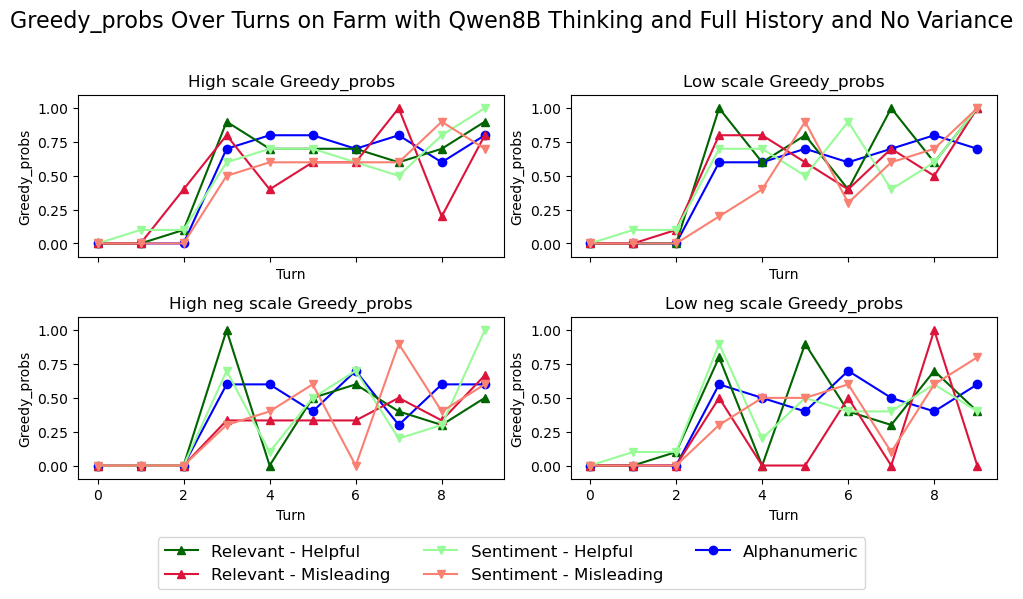

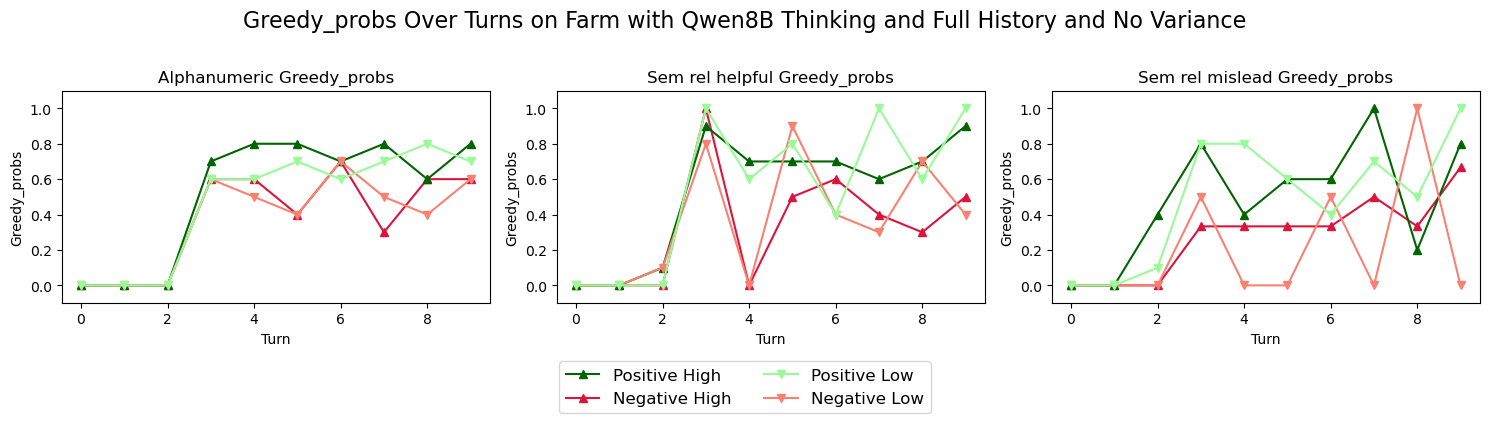

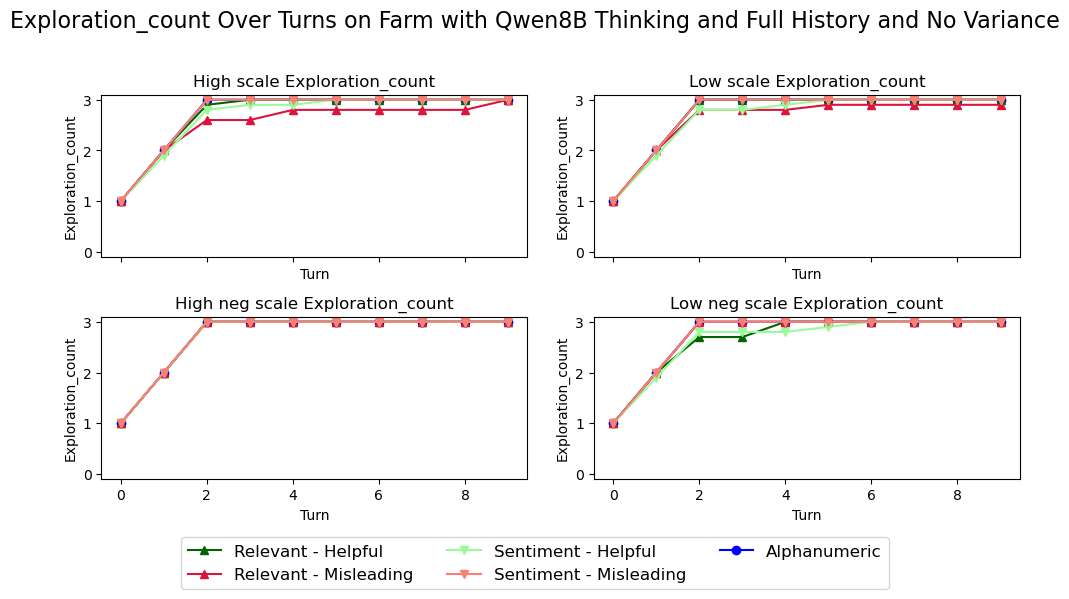

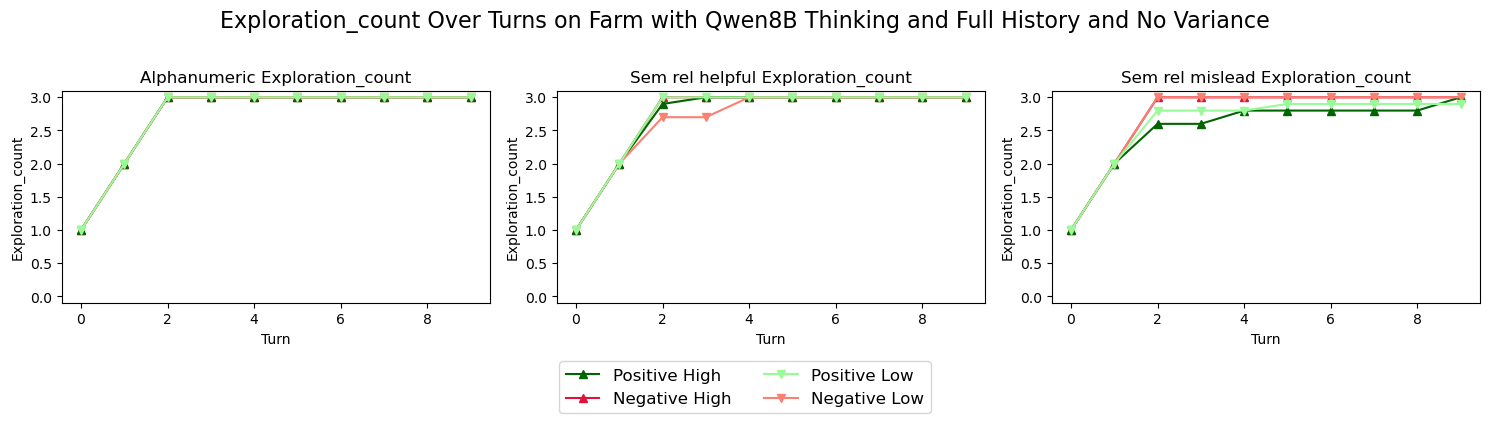

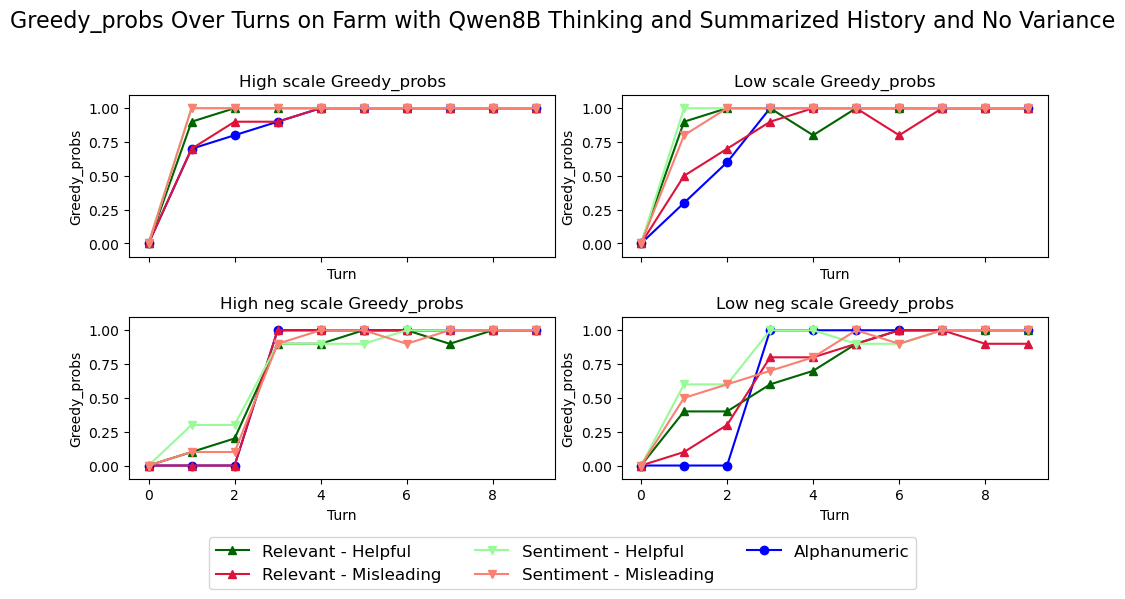

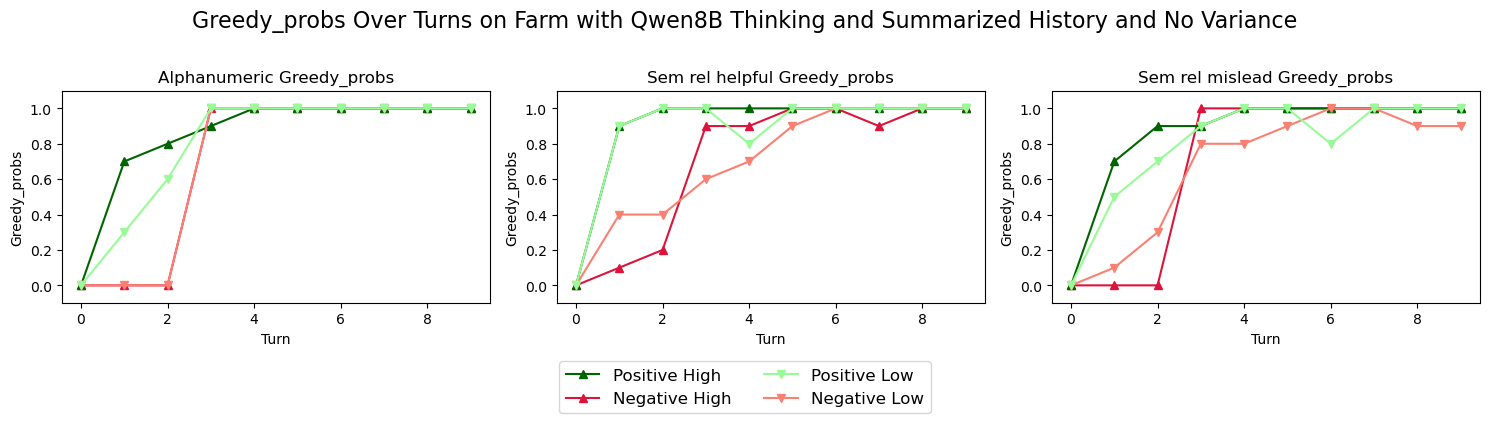

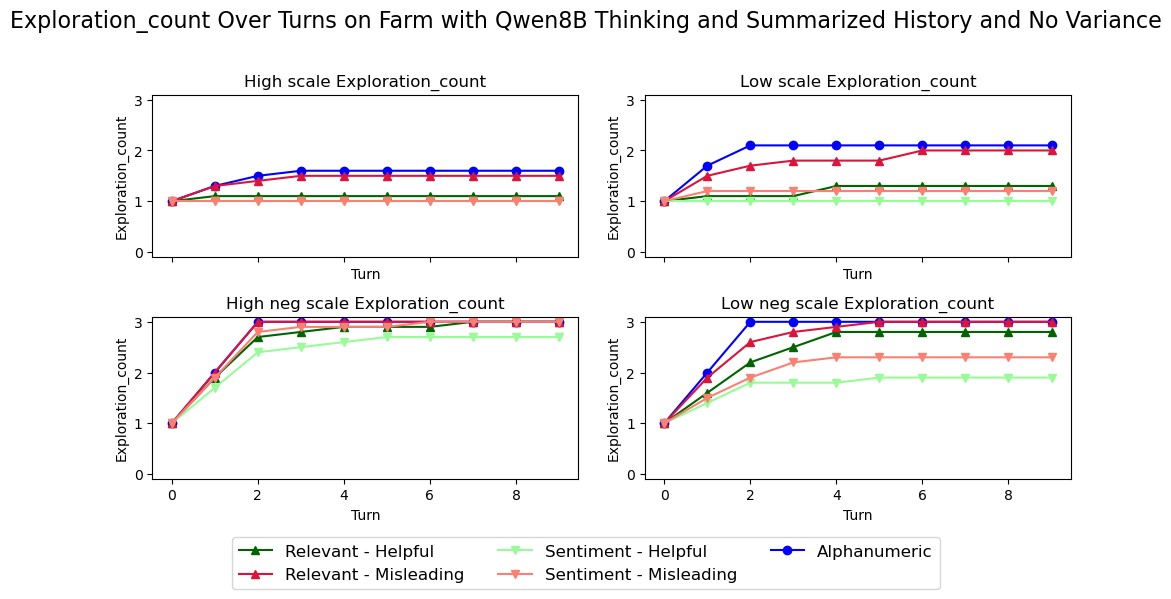

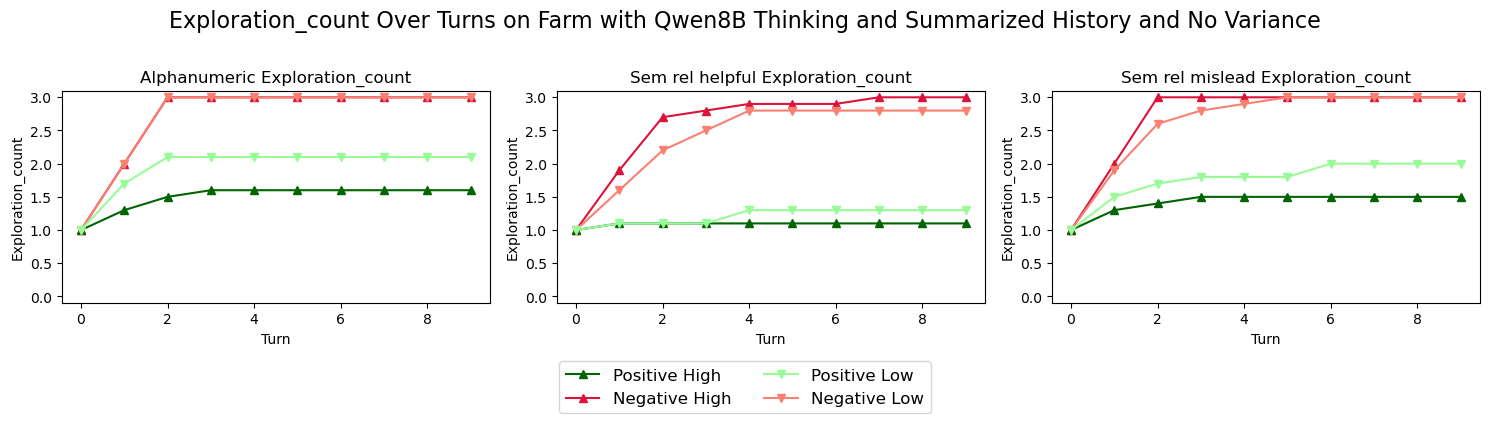

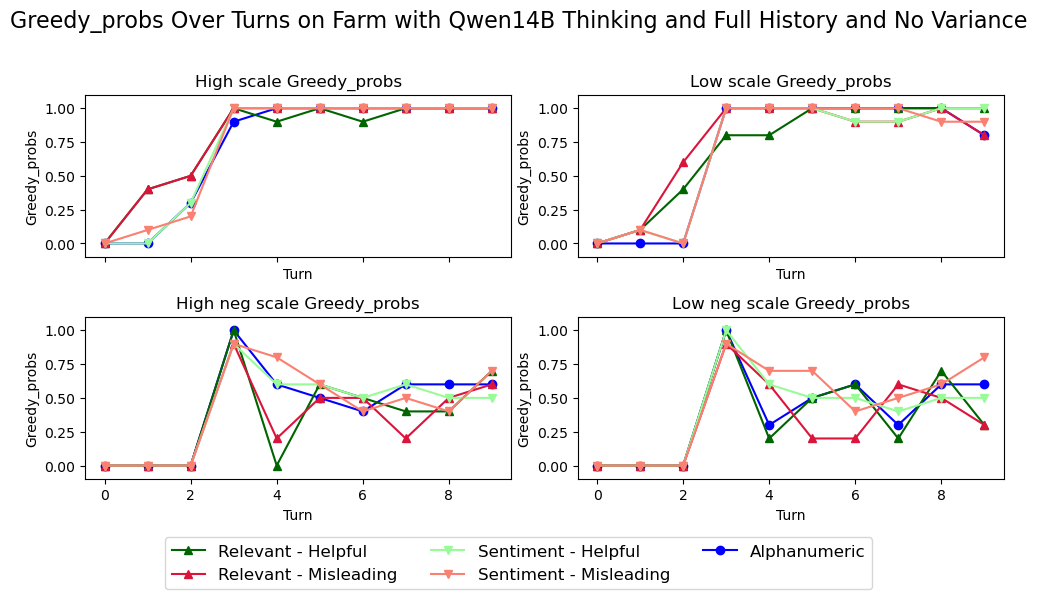

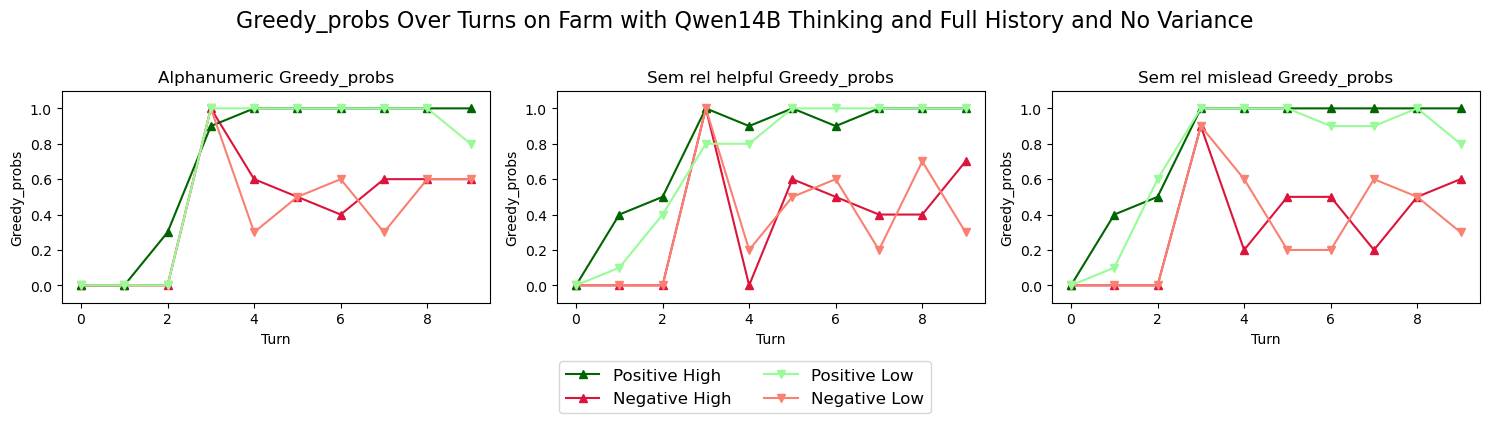

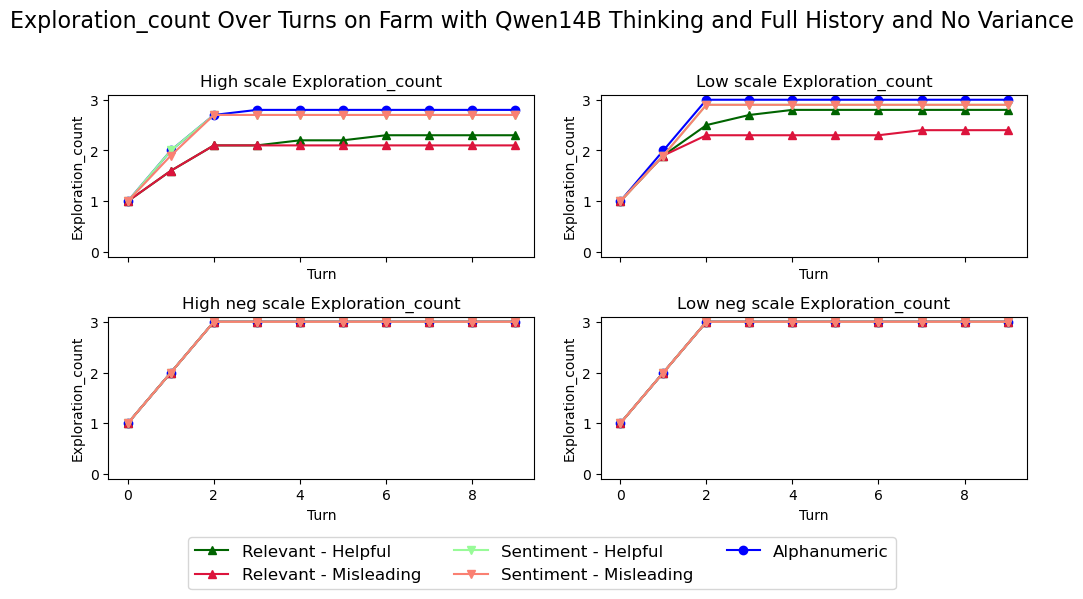

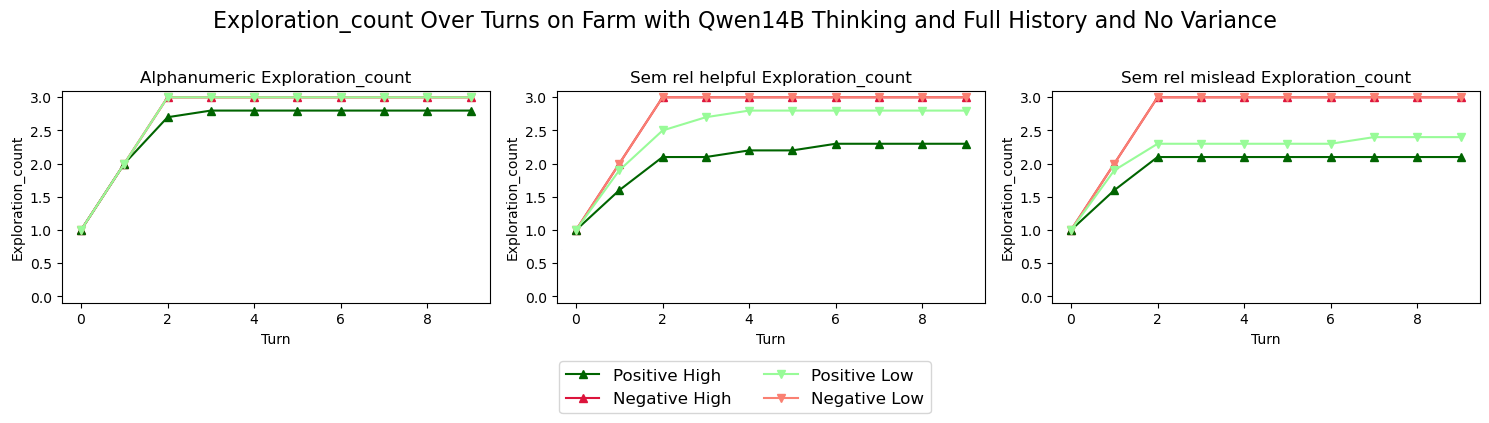

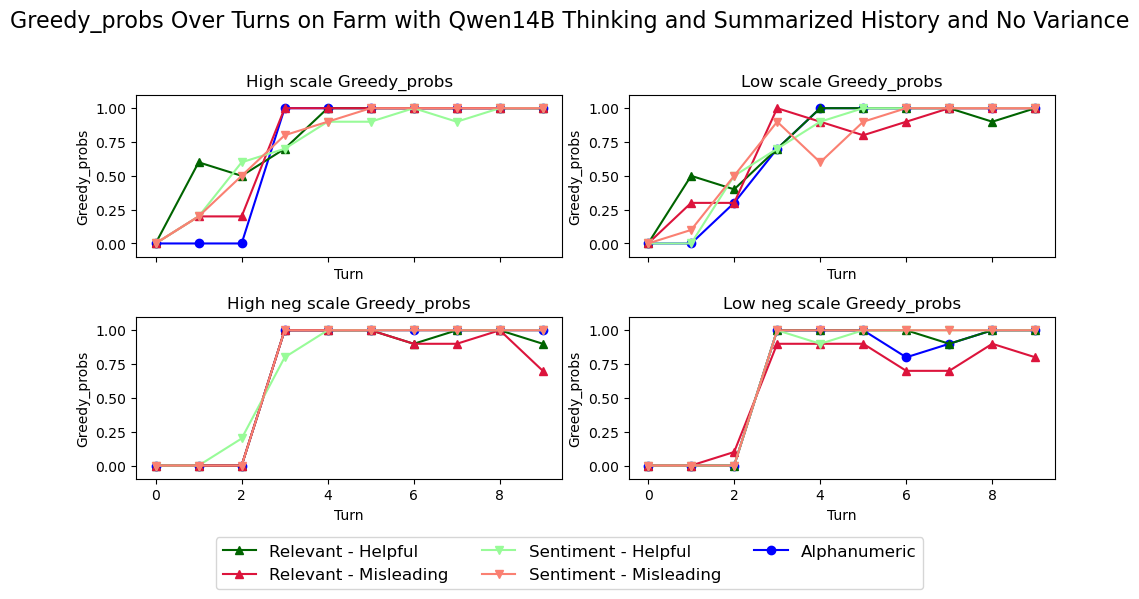

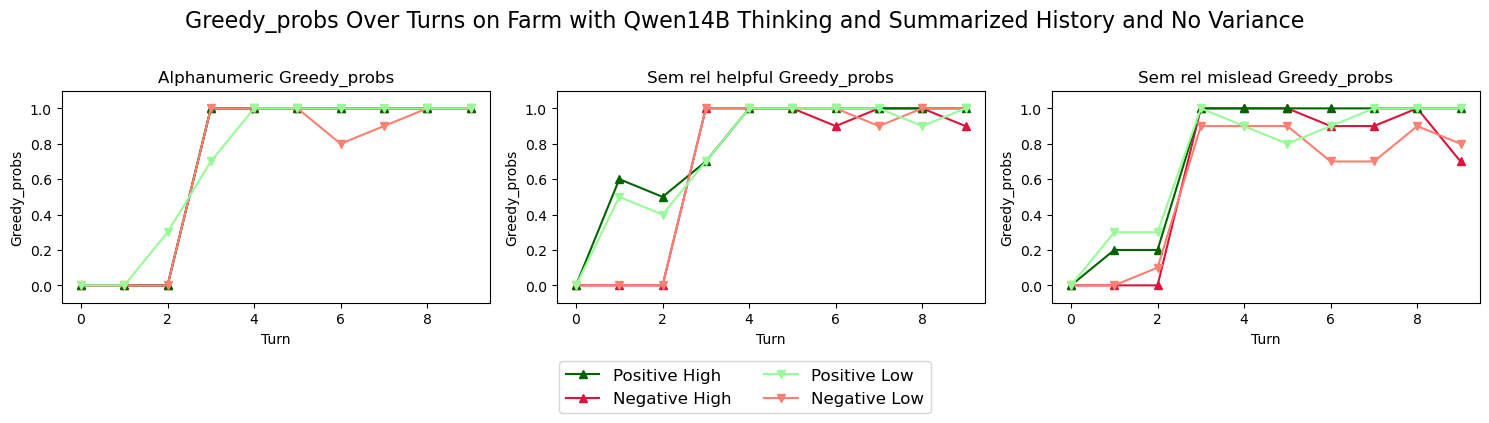

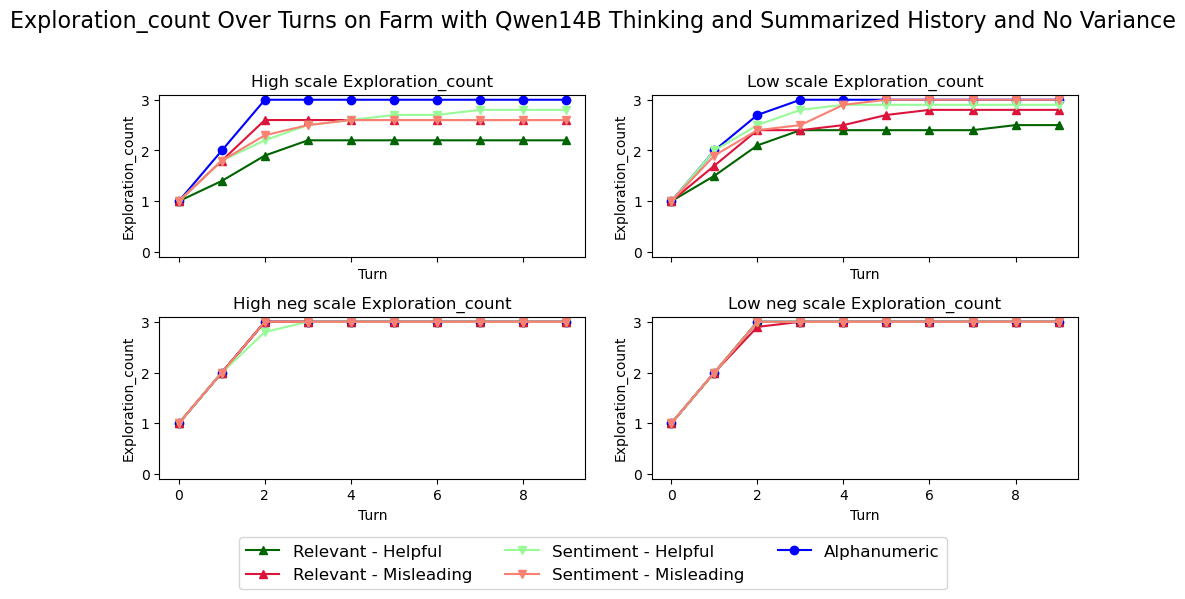

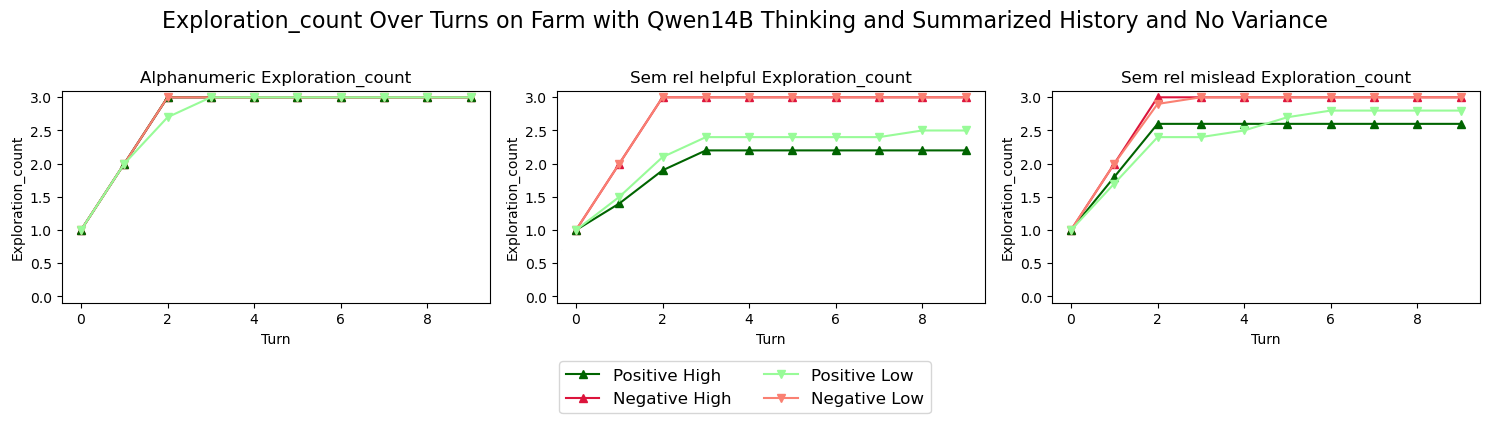

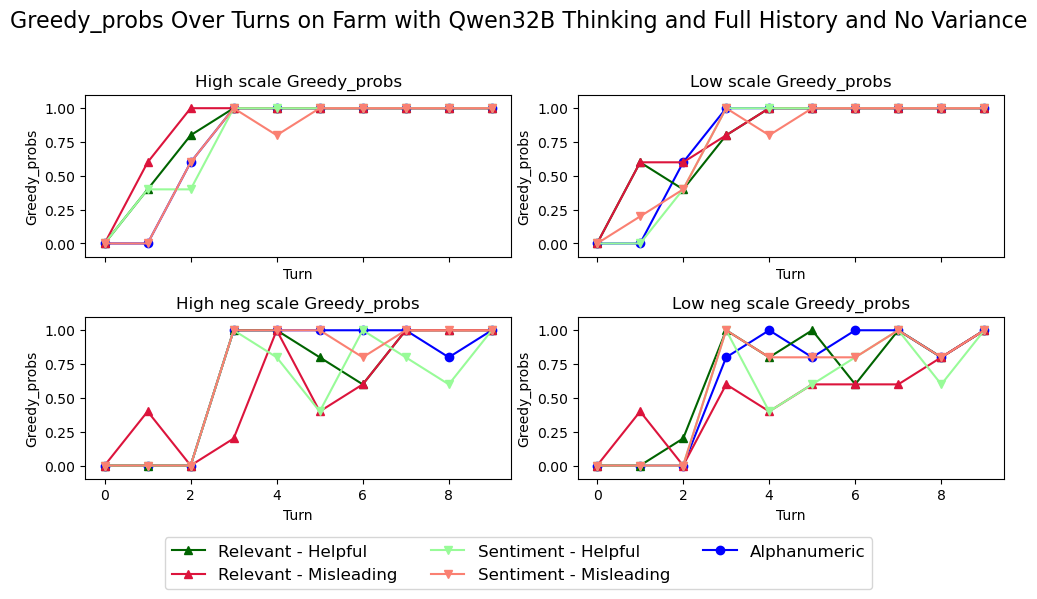

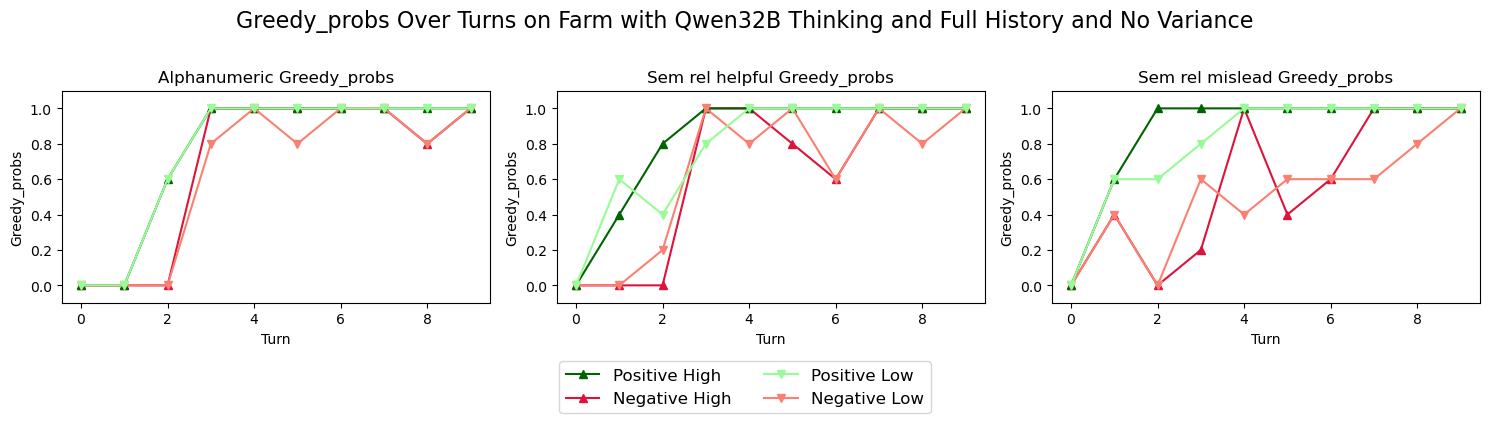

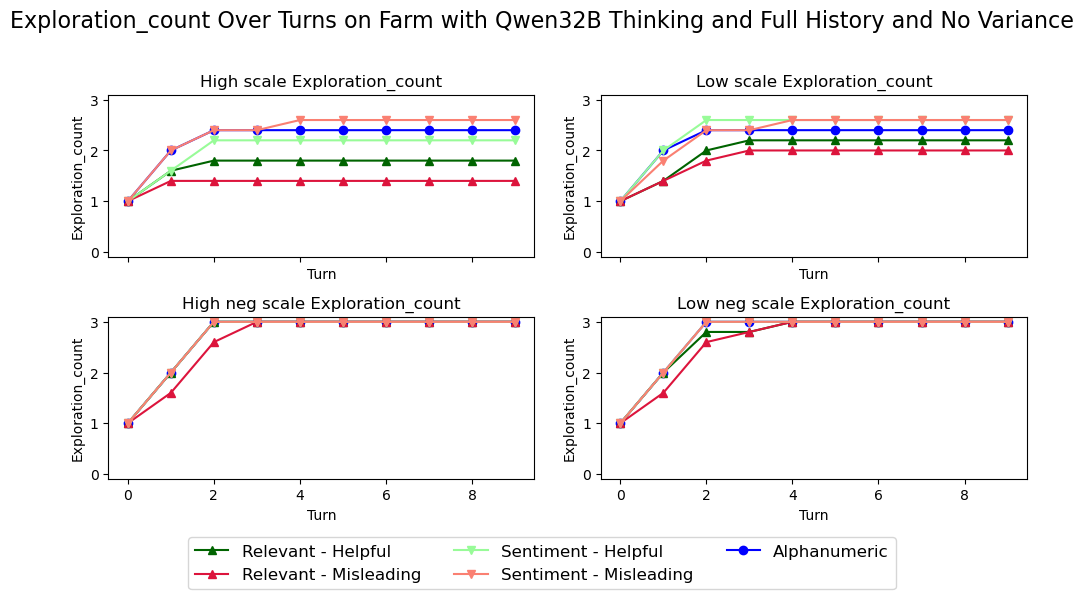

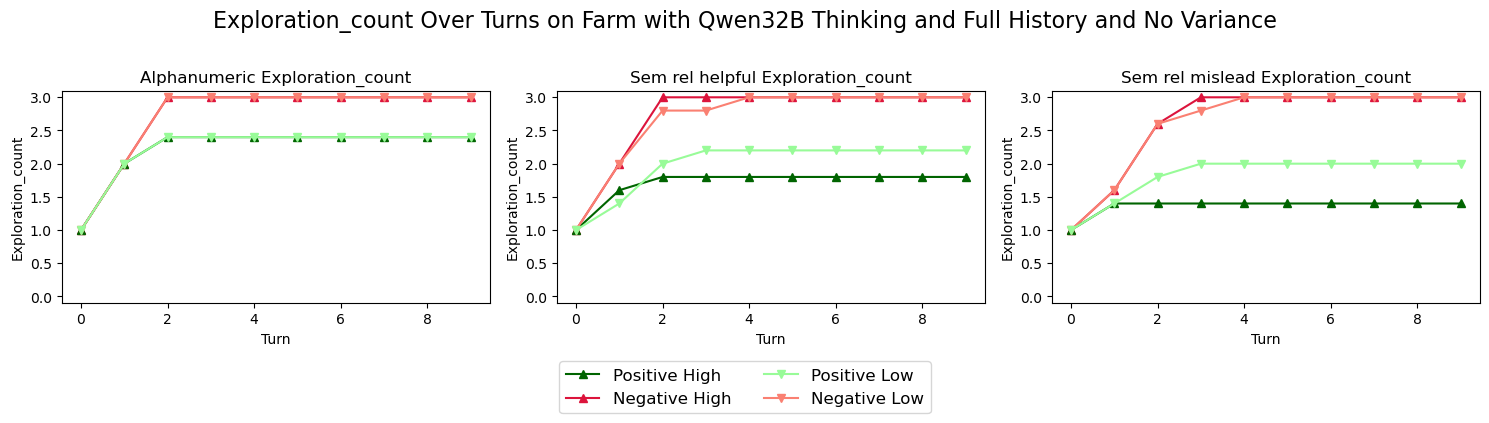

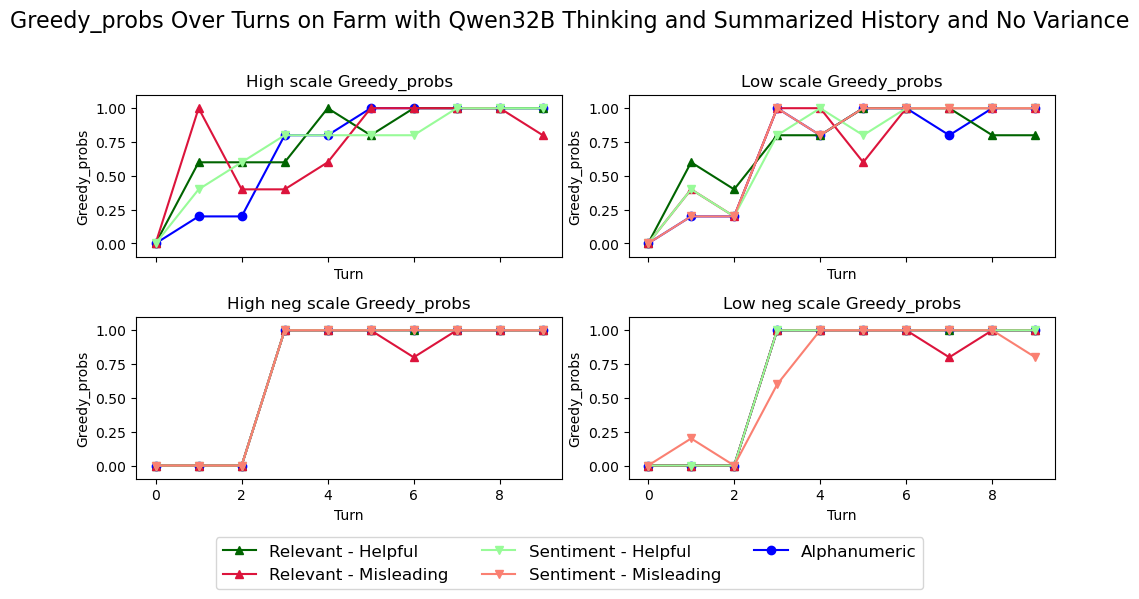

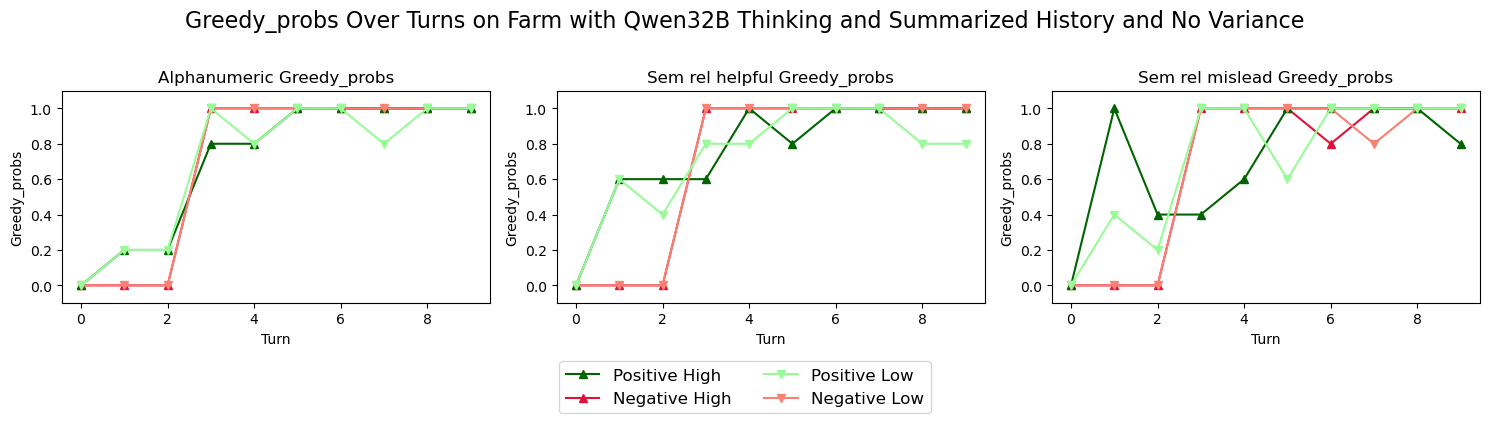

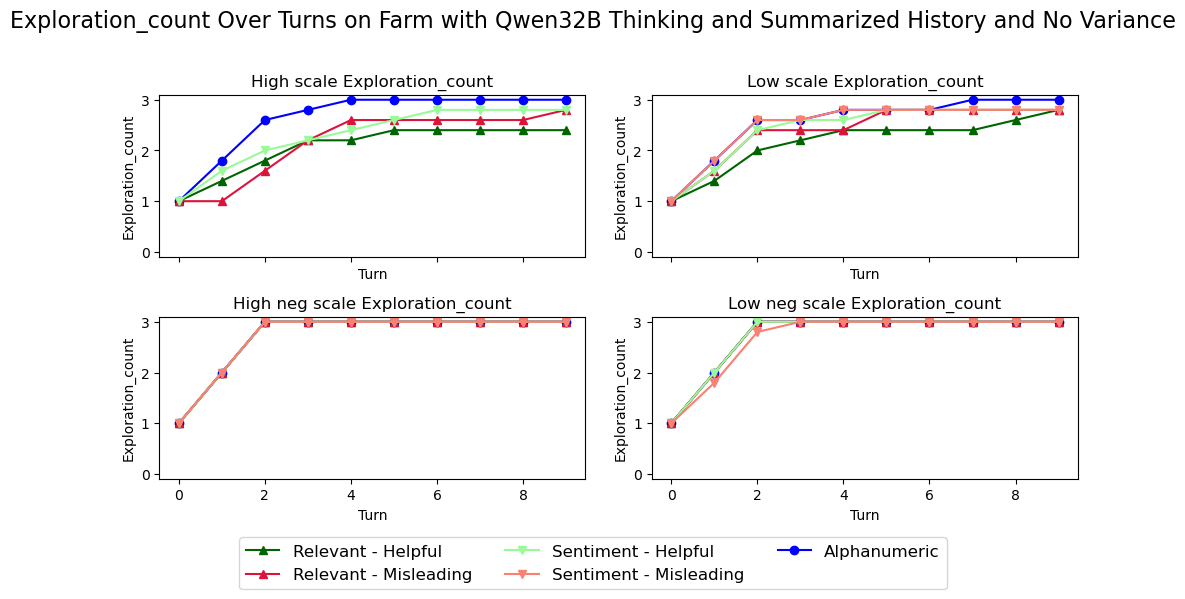

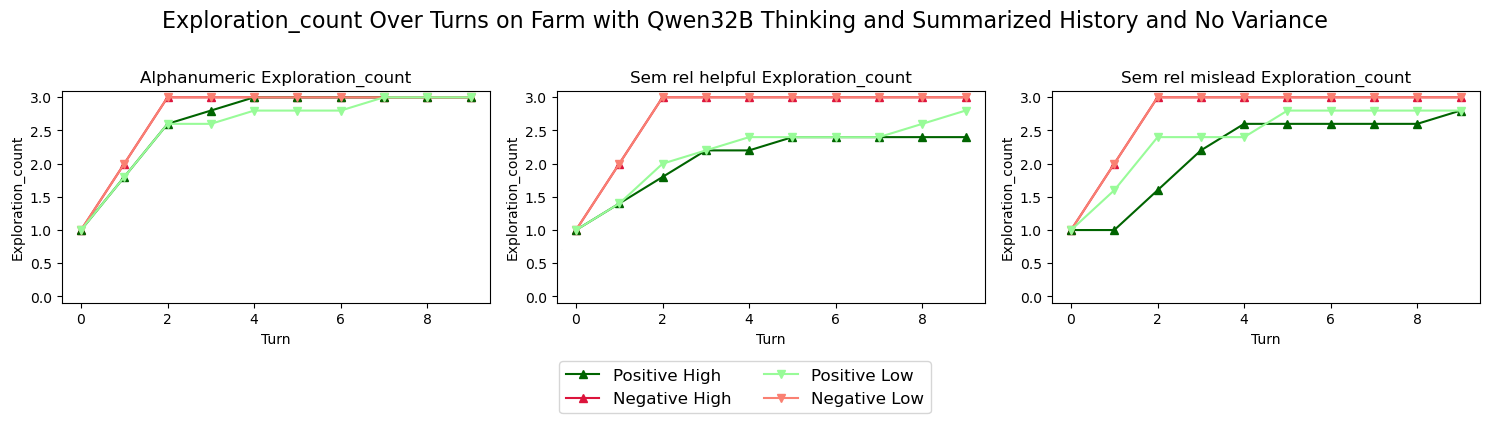

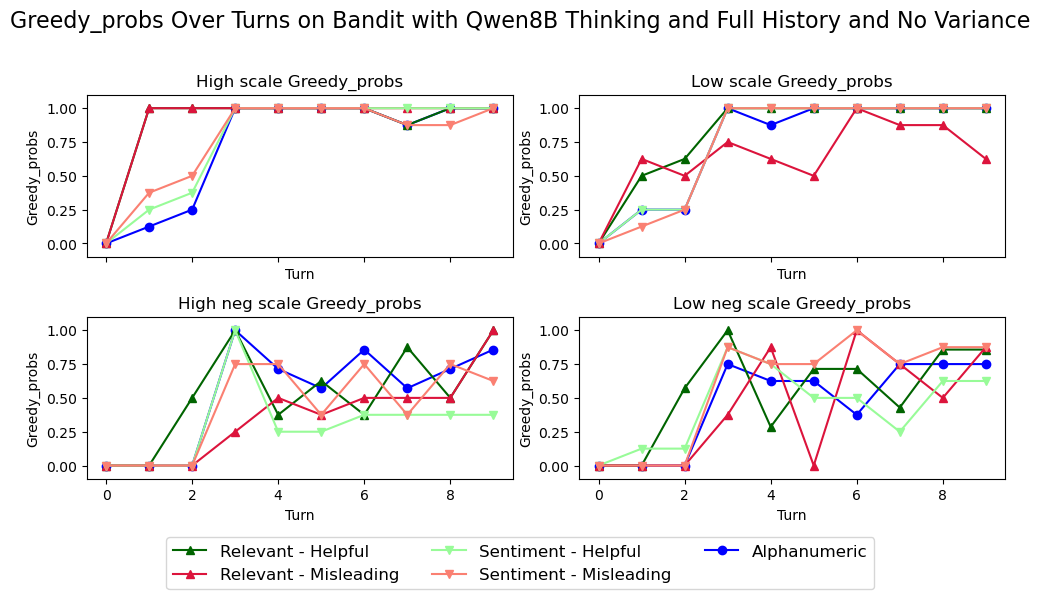

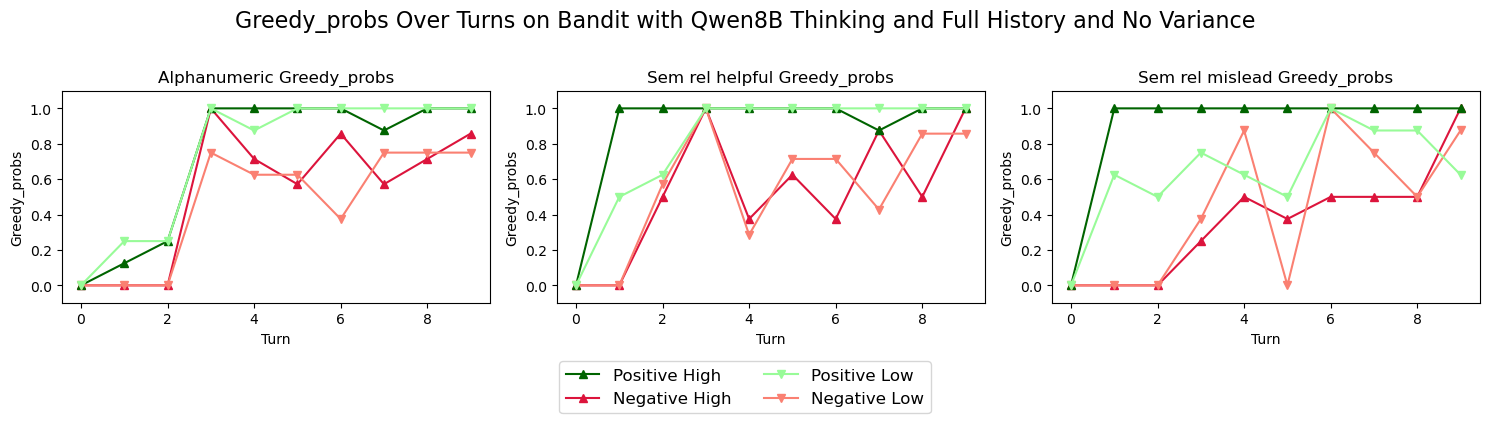

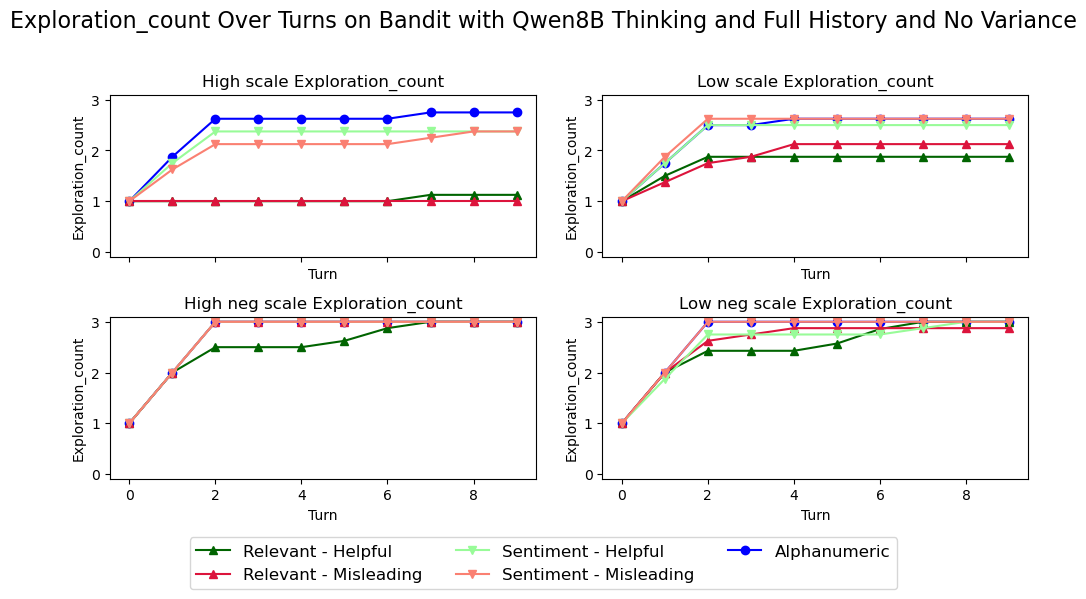

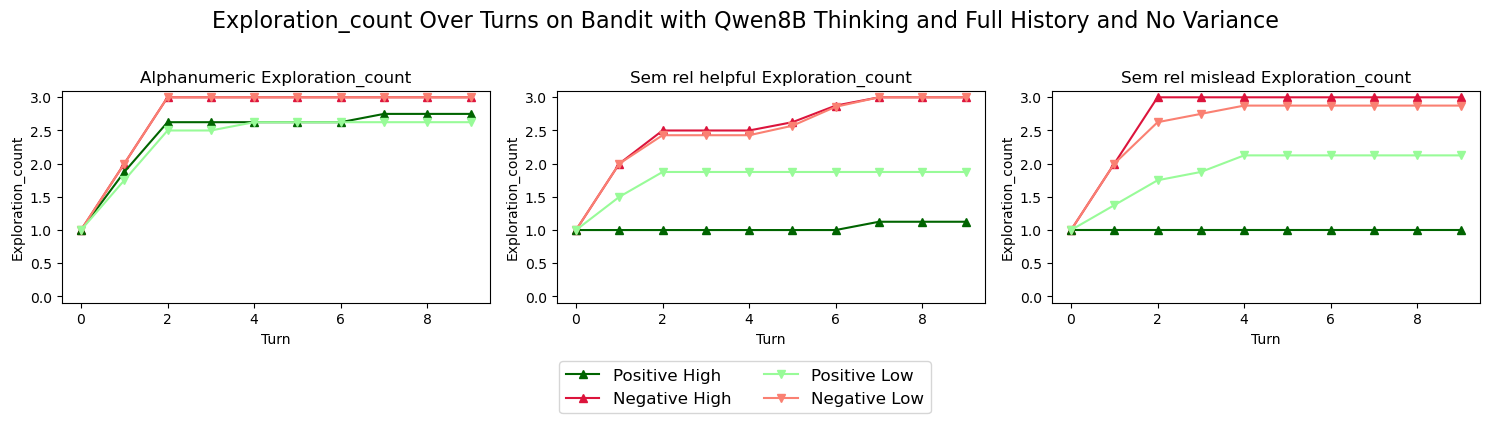

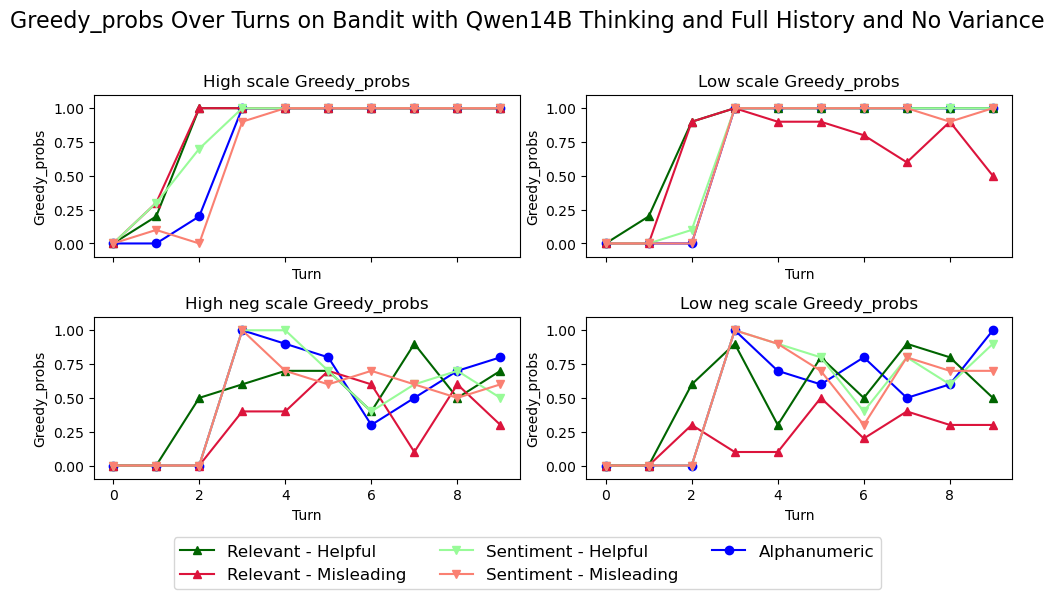

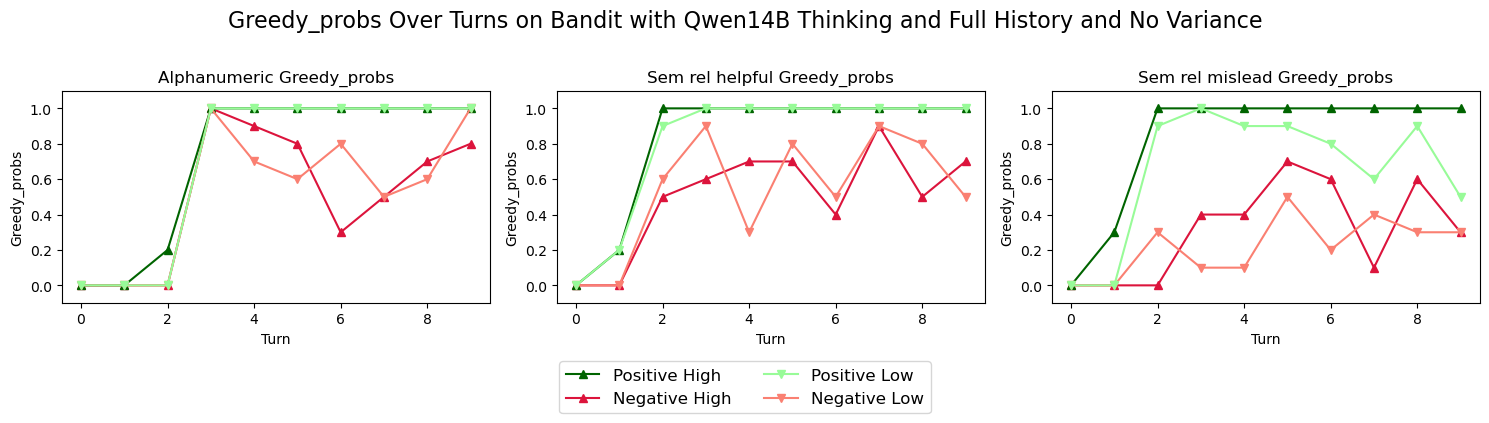

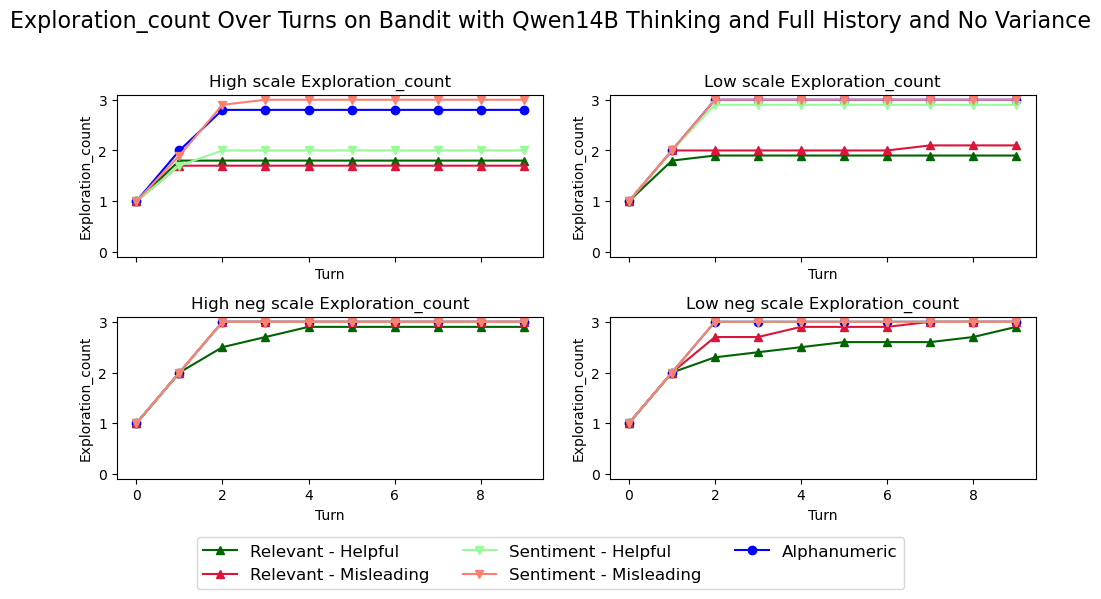

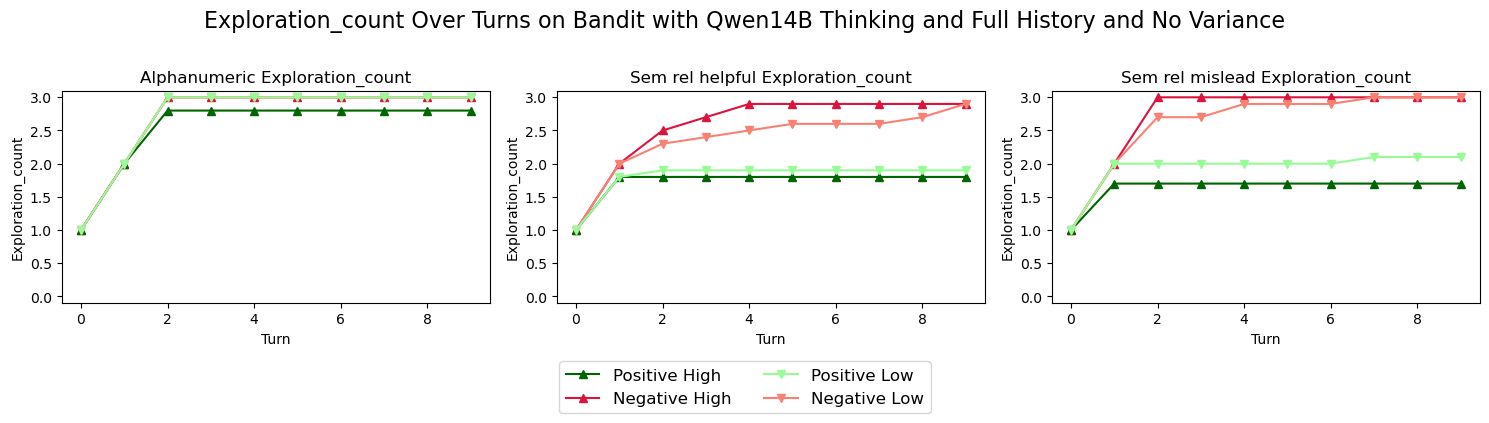

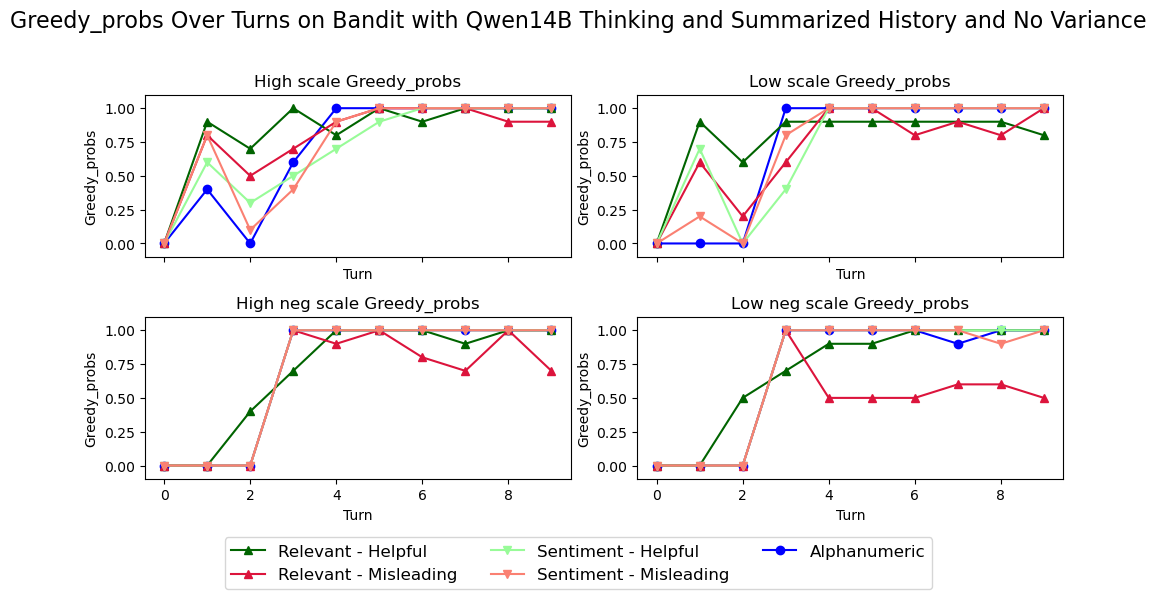

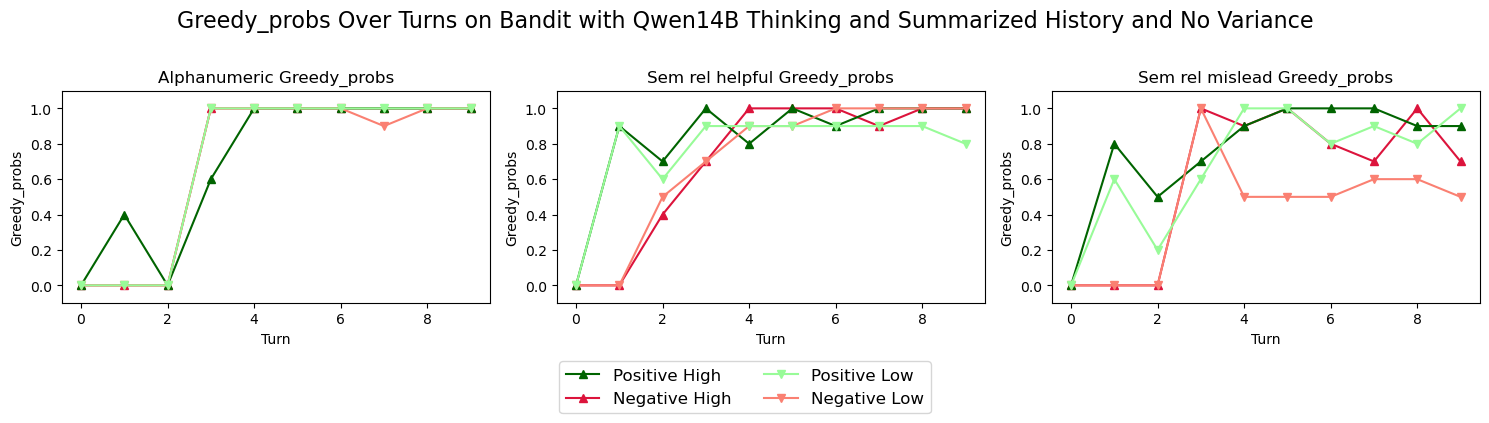

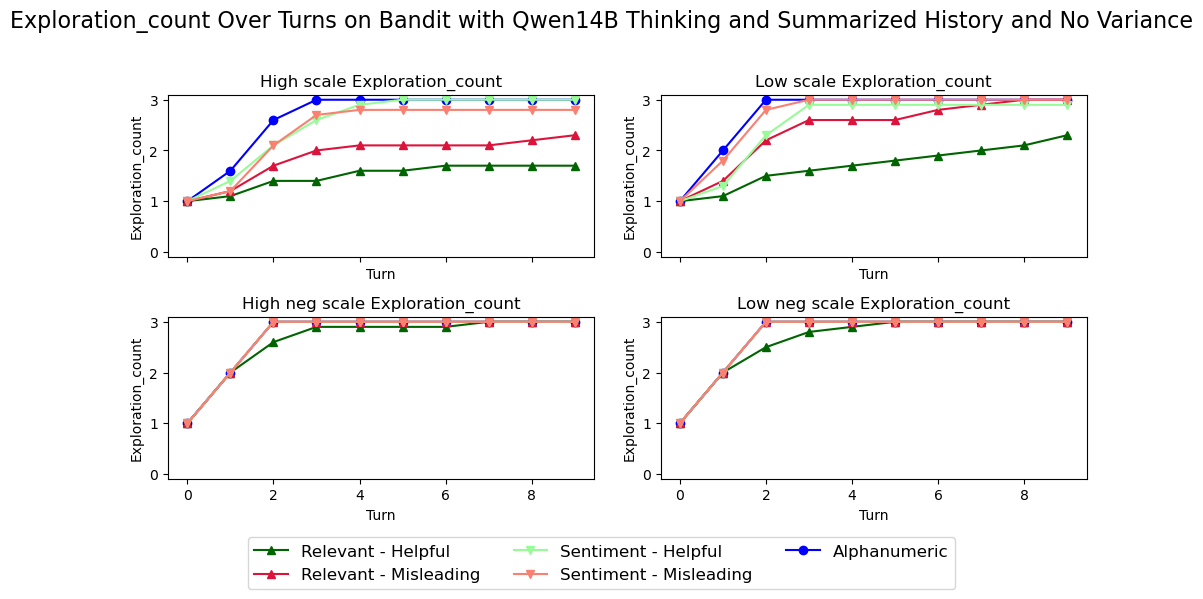

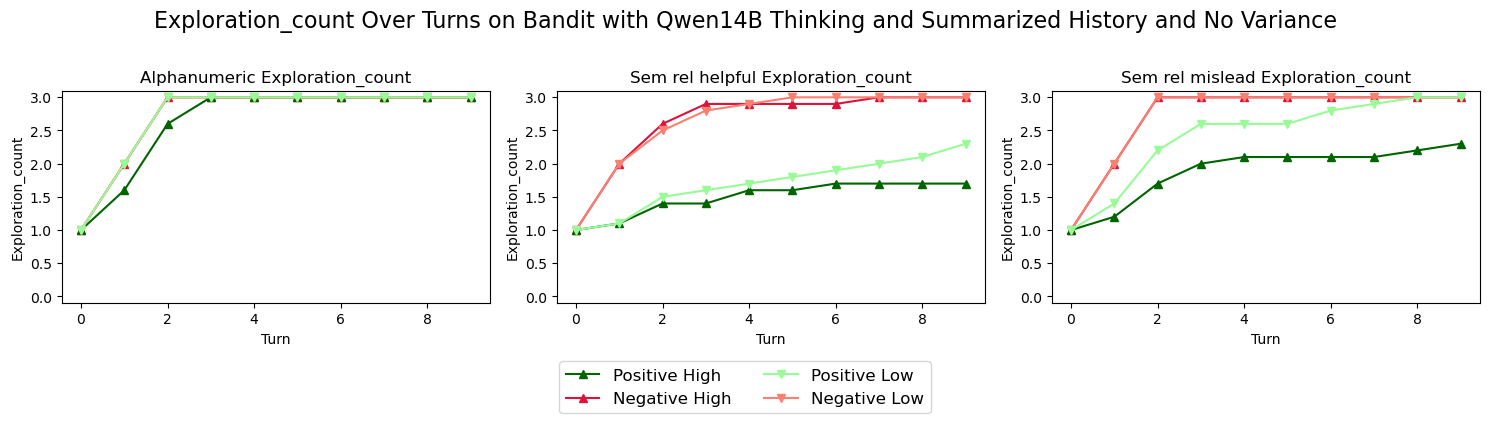

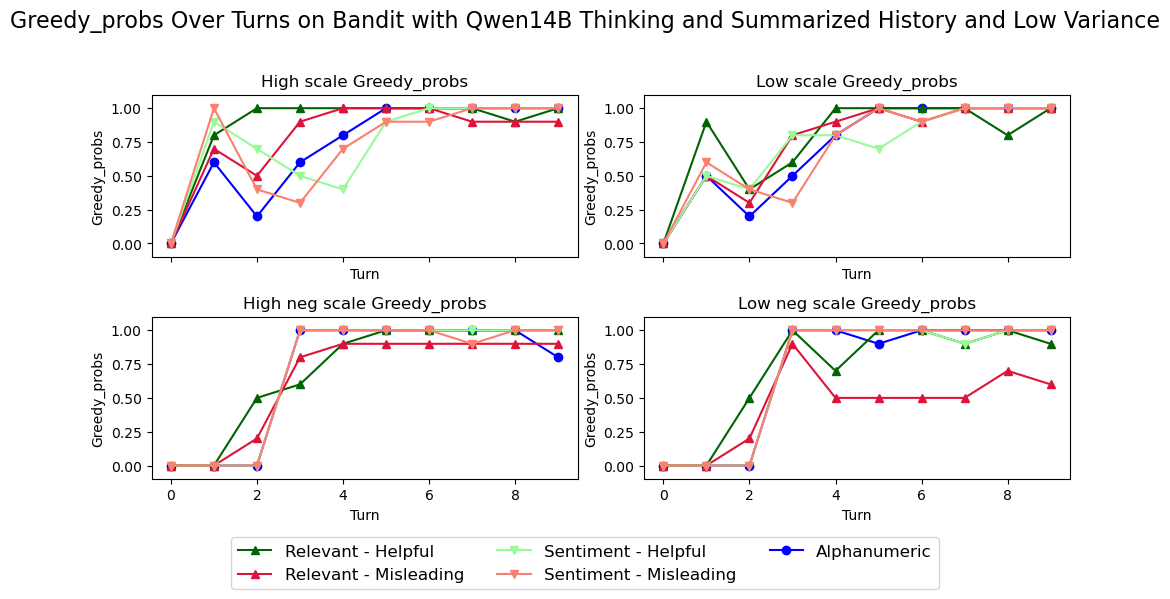

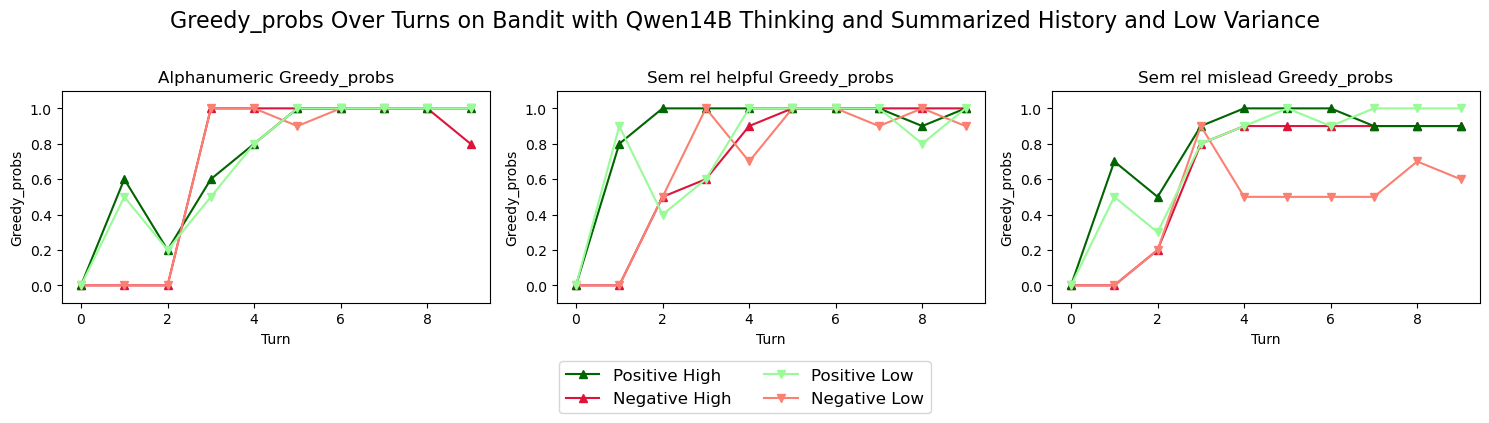

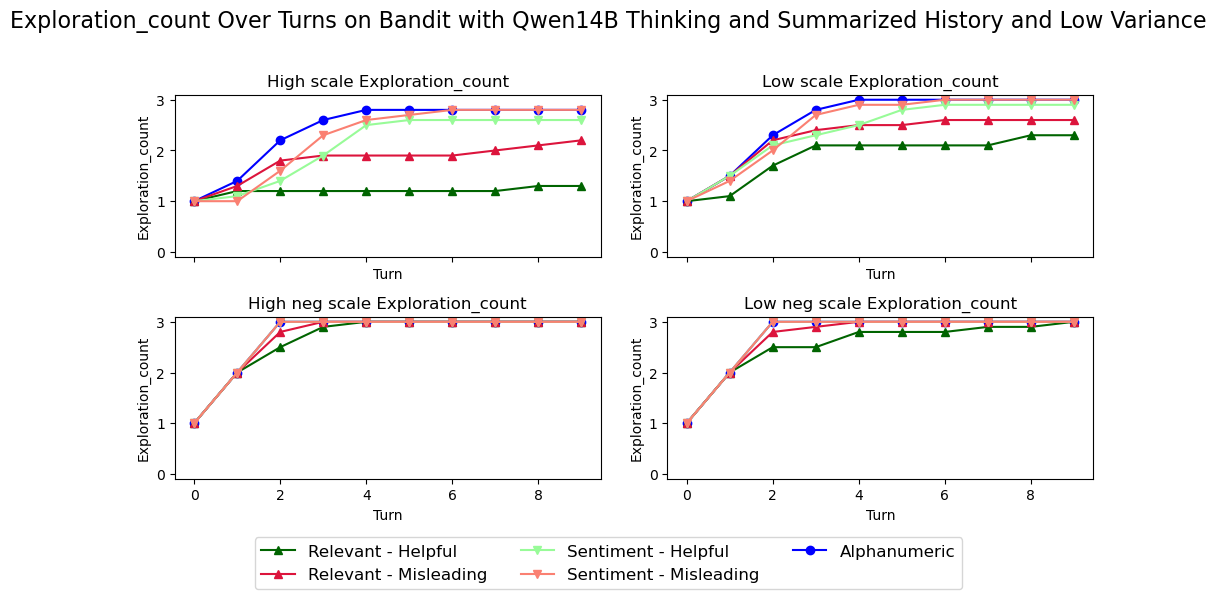

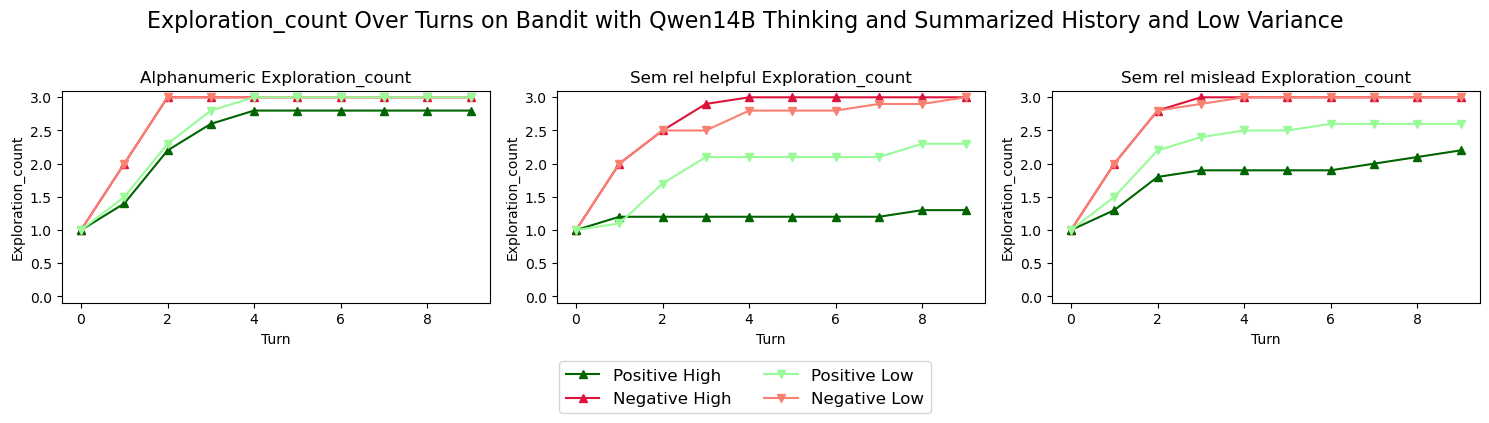

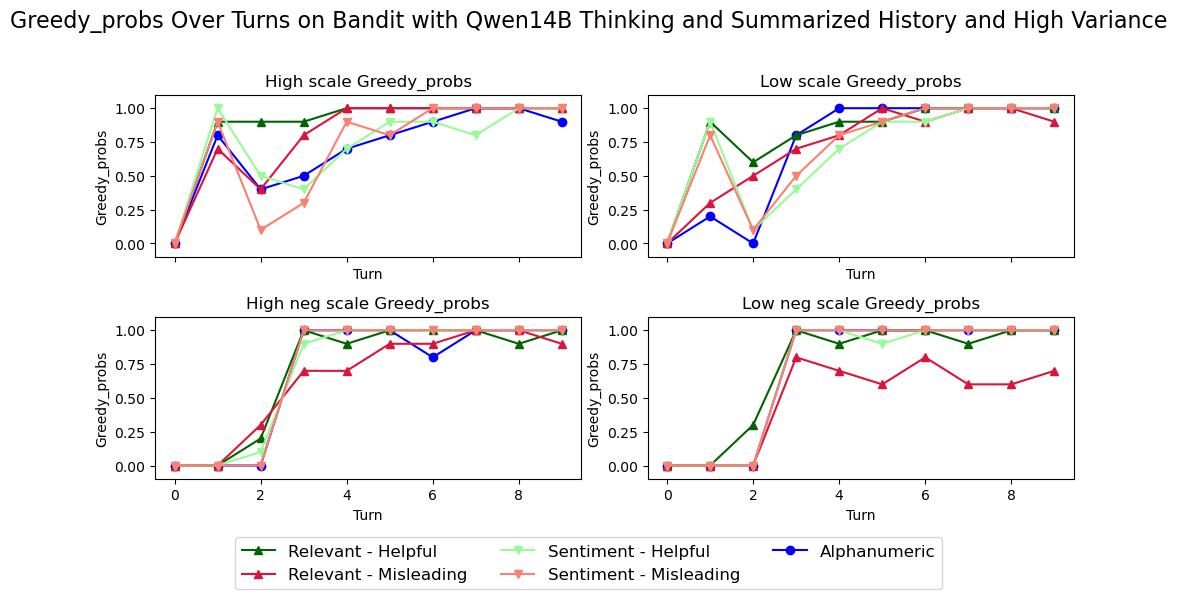

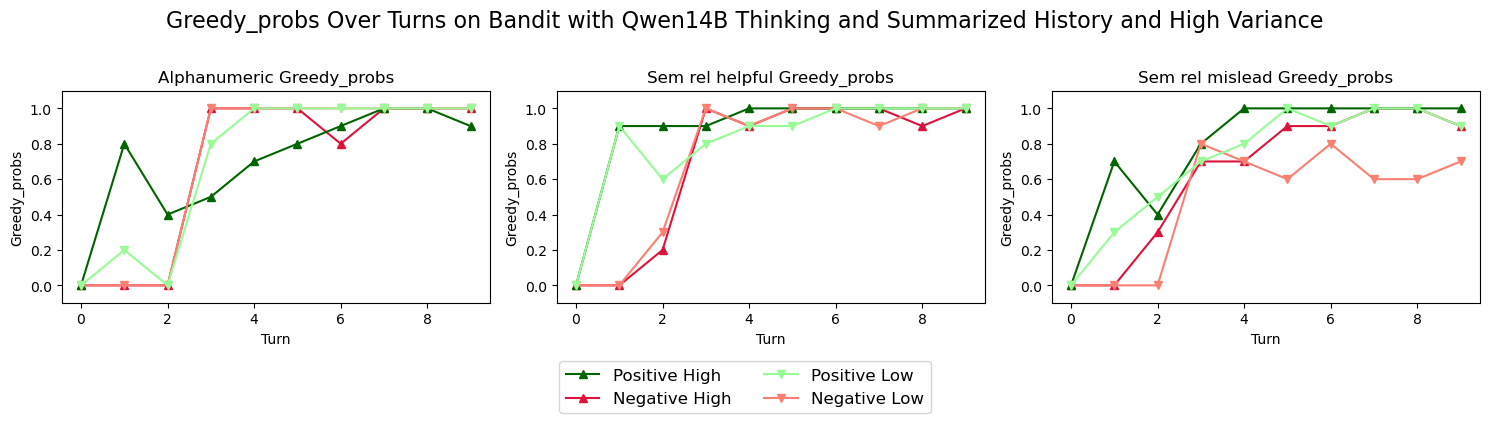

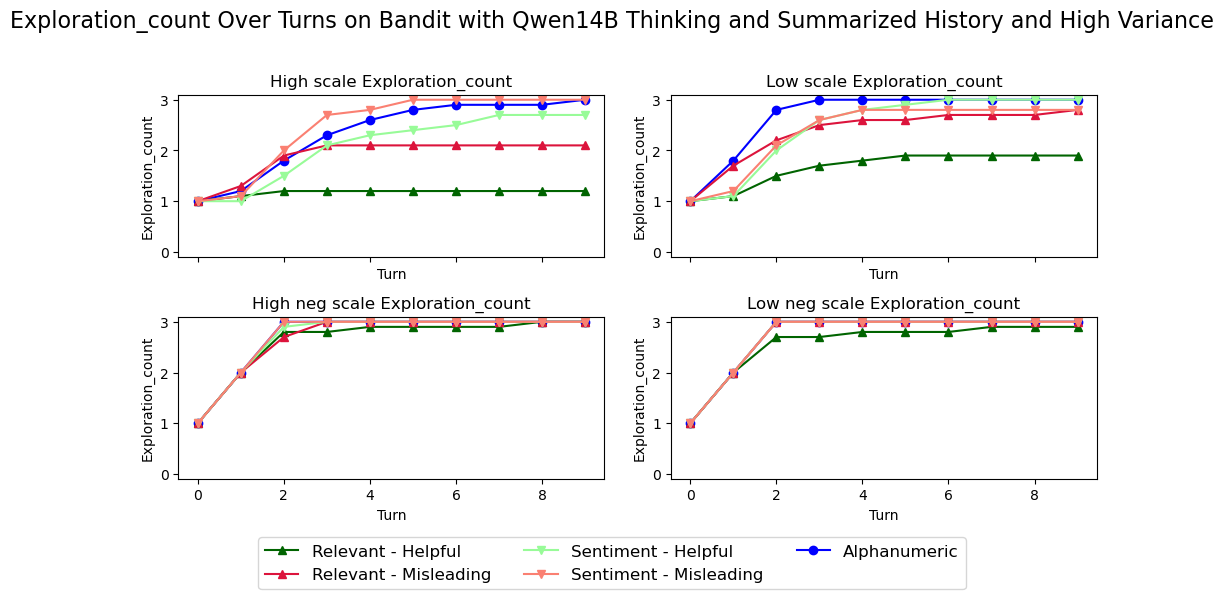

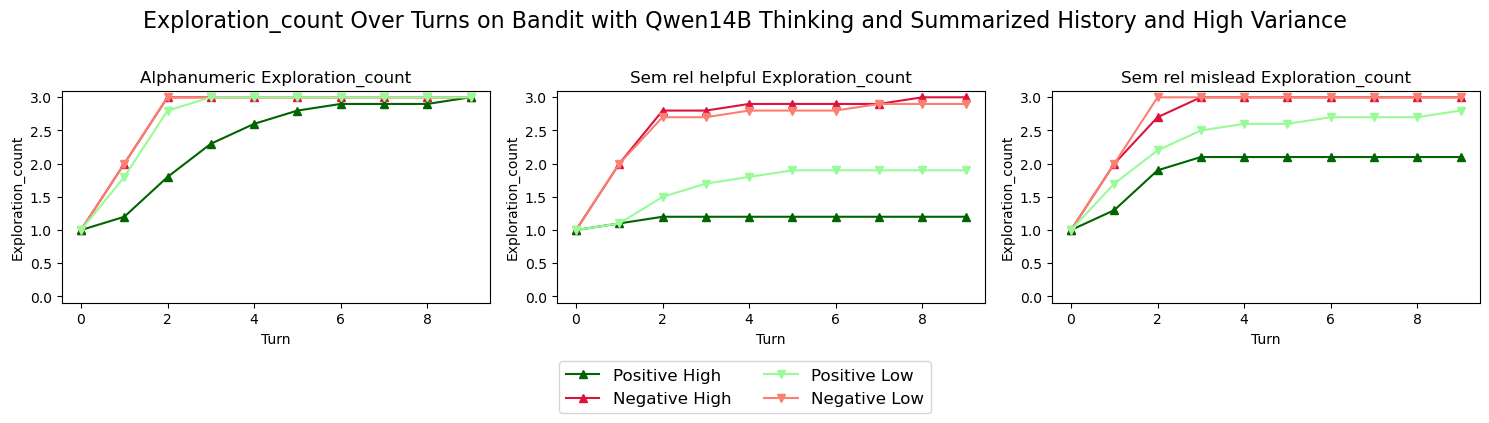

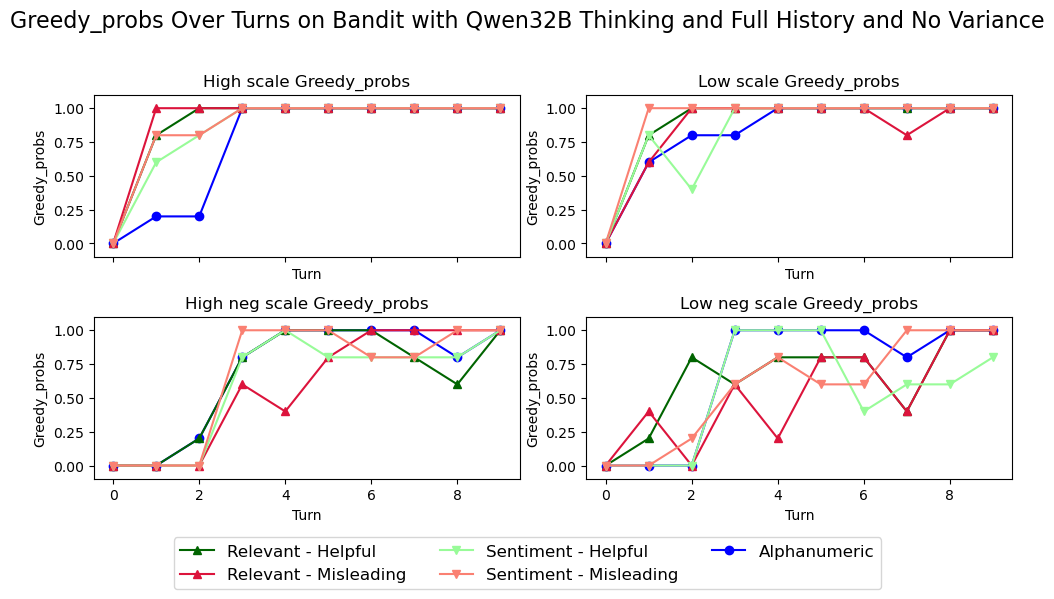

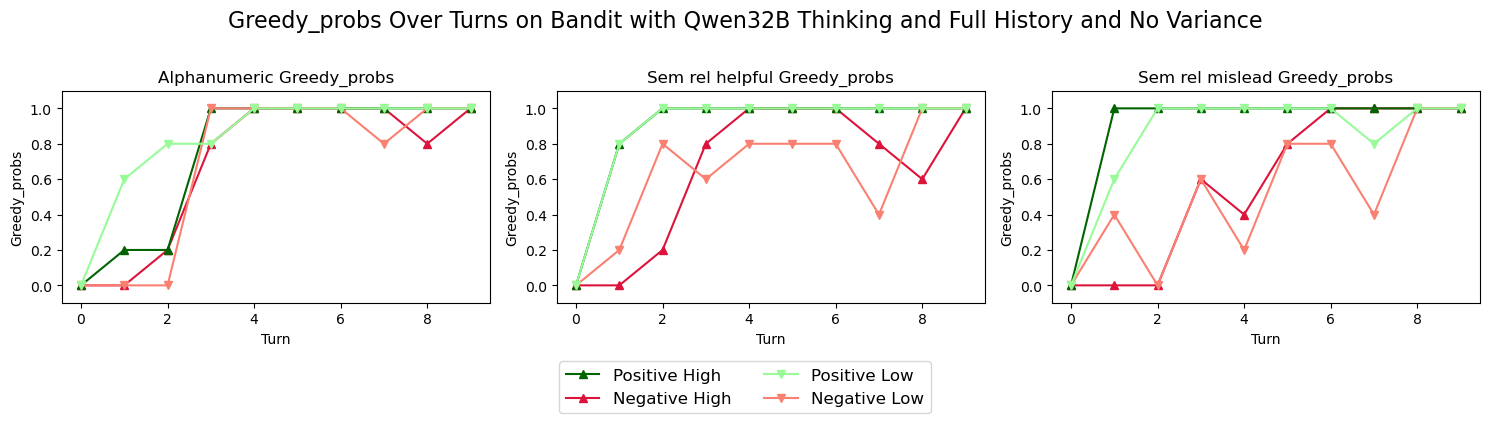

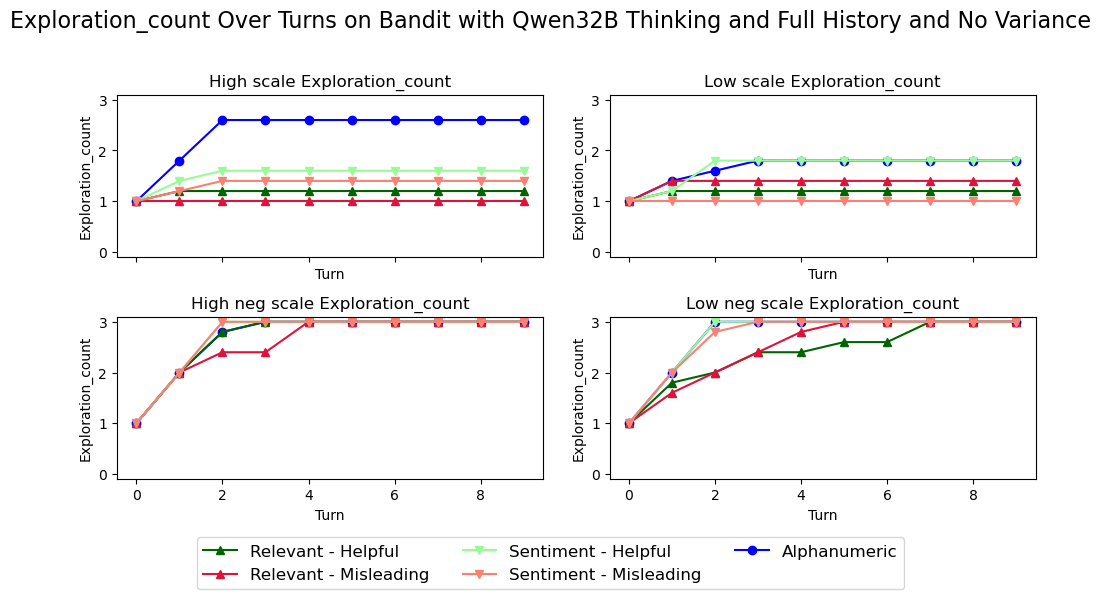

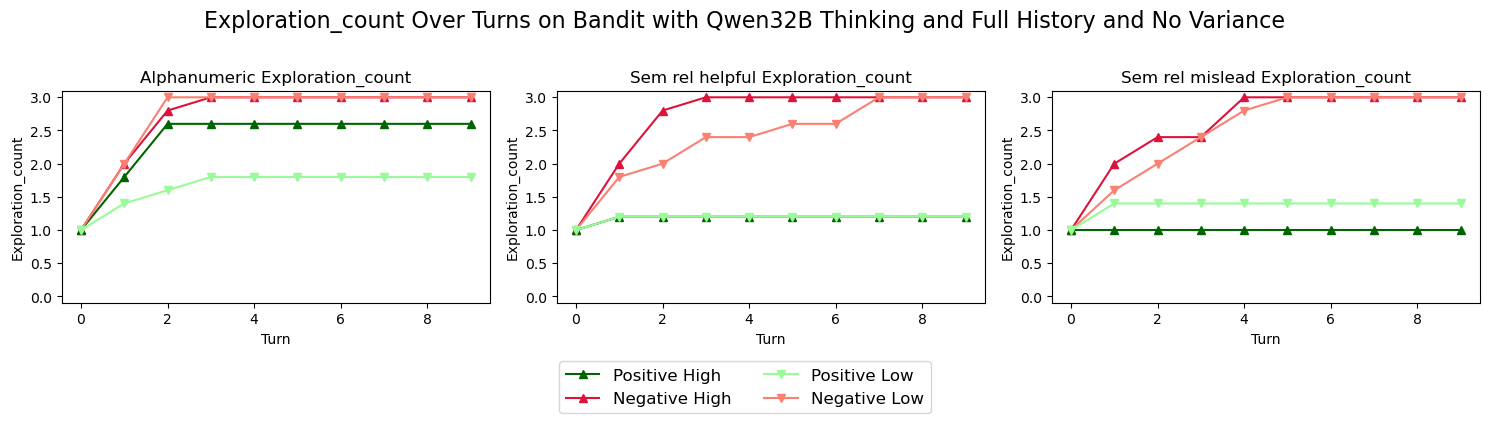

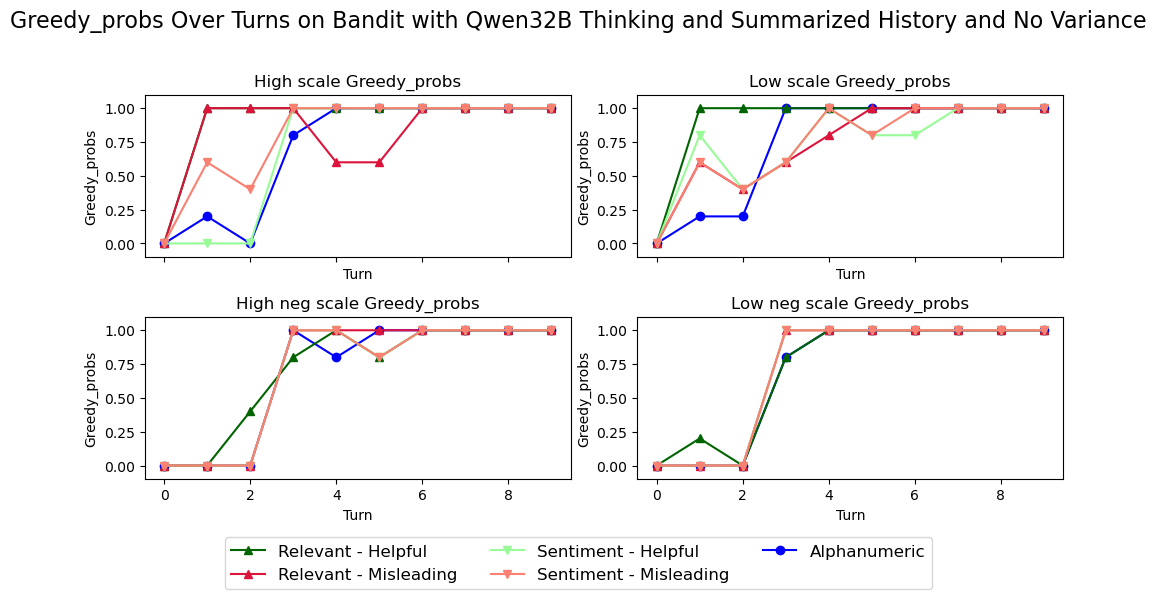

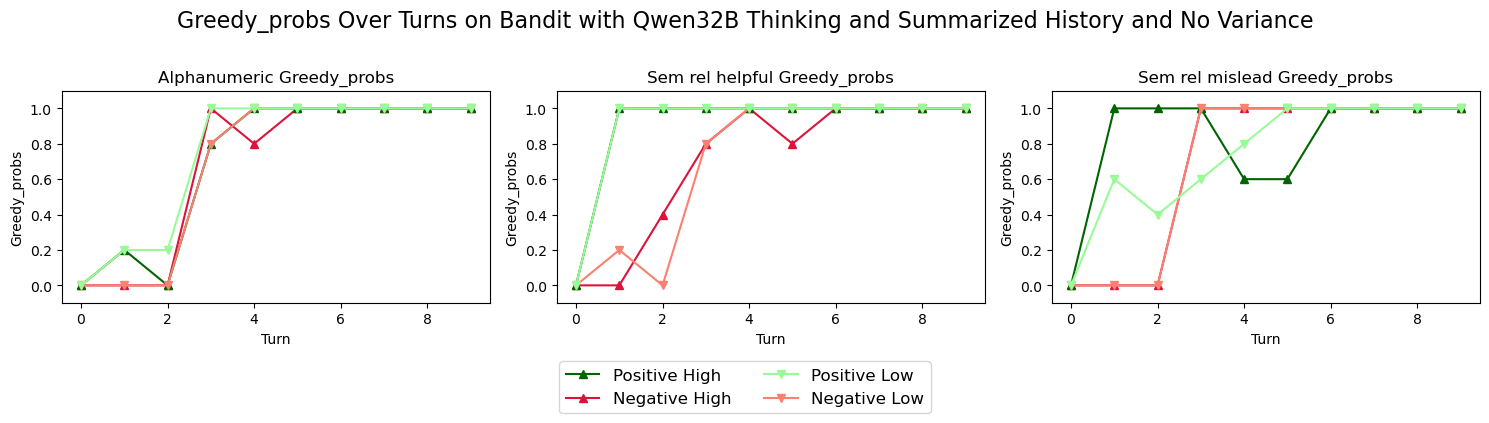

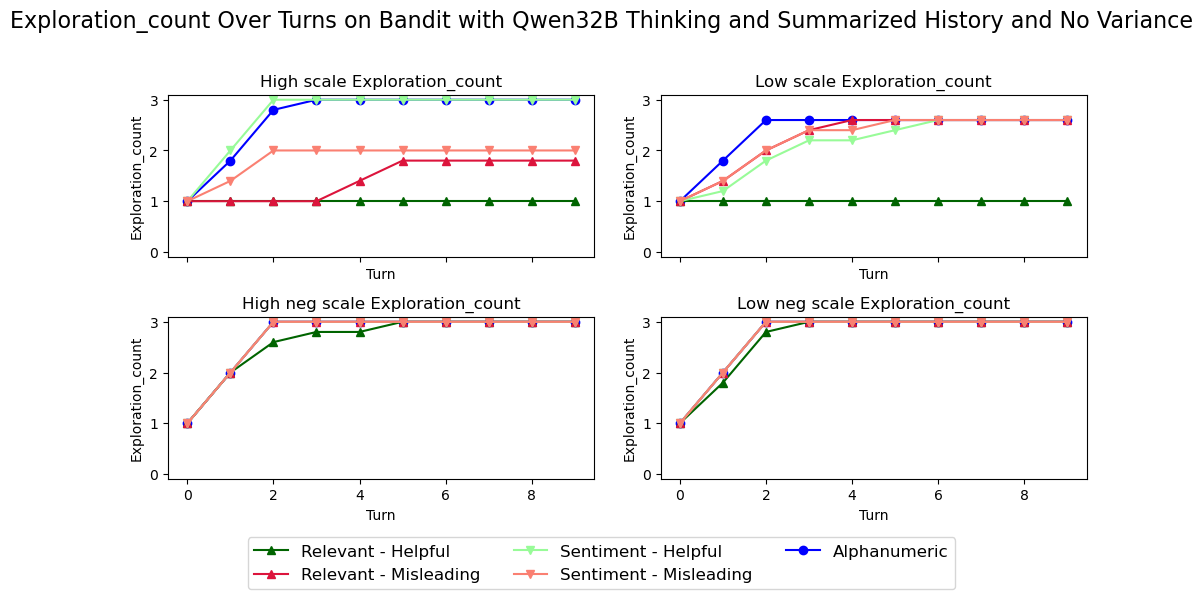

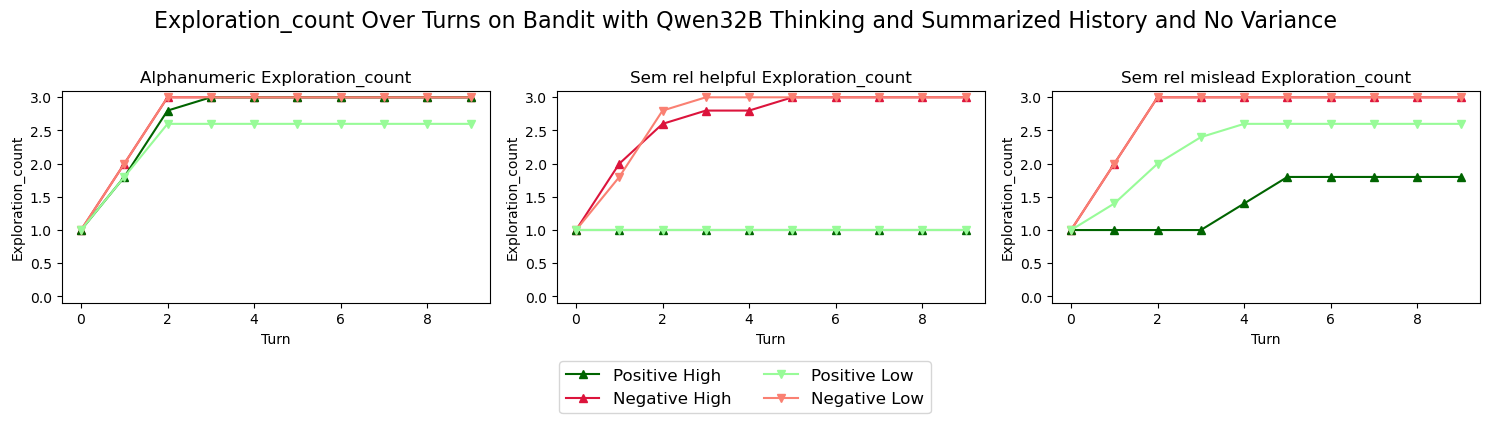

In [8]:
## First, we load in the merged dataframe
eval_path = 'experiments/merged_eval_results.csv'
results_df = load_csv(eval_path)

scale_label = 'scale'
nom_label = 'nomenclature'

# metrics = ['cum_regret', 'sem_optimal_actions', 'reward_optimal_actions']
metrics = ['greedy_probs', 'exploration_count']

for domain in results_df['Domain'].unique():
    for model in results_df['Model'].unique():
        for hist in results_df['History'].unique():
            for variance in results_df['Variance'].unique():
                subset = results_df[(results_df['Model'] == model) & (results_df['History'] == hist) & (results_df['Domain'] == domain) & (results_df['Variance'] == variance)]
                if subset.empty:
                    continue  # Skip if subset is empty
                save_path_detail = f"/{model}/{hist}/{domain}/{variance}"
                for metric_key in metrics:
                    title = f"{metric_key.capitalize()} Over Turns on {domain} with {model} Thinking and {hist} History and {variance} Variance"
                    plot_exploration_with_magnitude_subplots(subset, metric_key, subplot_col=scale_label, legend_col=nom_label, title=title, include_std=False, save_path_detail=save_path_detail)
                    plot_exploration_with_nomenclature_subplots(subset, metric_key, subplot_col=nom_label, legend_col=scale_label, title=title, include_std=False, save_path_detail=save_path_detail)